# **데이터 로드 및 증강**

In [1]:
# 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 모델 분석 및 시각화 도구
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import xml.etree.ElementTree as ET
from PIL import Image
from collections import Counter
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Scikit-learn (데이터 전처리 및 모델 평가)
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, LabelBinarizer

# 모델 설계
import tensorflow as tf

# 모델 구조 및 레이어
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Input, Dense, Conv2D, MaxPooling2D,
Flatten, Dropout, BatchNormalization,
LeakyReLU, GlobalAveragePooling2D, concatenate)

# 사전 훈련된 모델
from tensorflow.keras.applications import EfficientNetB0, ResNet50, MobileNetV2, MobileNetV3Small, VGG16, InceptionV3, Xception, DenseNet121

# 컴파일 및 훈련 관련
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

In [3]:
# 이미지 파일과 CSV 파일 로드 함수
def load_original_data(csv_path, image_root, image_size):
    df = pd.read_csv(csv_path)

    images, coords, labels = [], [], []
    for _, row in tqdm(df.iterrows(), total=df.shape[0]):
        img_path = os.path.join(image_root, row['class'], row['cropped_image'])
        img = cv2.imread(img_path)
        if img is None:
            print(f"경고: 이미지를 로드할 수 없습니다 - {img_path}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, image_size)

        coord_data = [row['x_center_norm'], row['y_center_norm'], row['width_norm'], row['height_norm']]

        images.append(img)
        coords.append(coord_data)
        labels.append(row['class'])

    print(f"-> 원본 데이터 로딩 완료: {len(images)}개 샘플")
    return np.array(images), np.array(coords), np.array(labels)

# 클래스 별 데이터의 개수를 맞추는 데이터 증강 함수
def balance_data_with_augmentation(original_images, original_coords, original_labels):

    # 데이터 증강 객체 정의
    datagen = ImageDataGenerator(
        rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
        zoom_range=0.1, horizontal_flip=True, vertical_flip=True, fill_mode='nearest'
    )

    # 클래스별 데이터 수 확인 및 목표 개수 설정
    class_counts = pd.Series(original_labels).value_counts()
    target_count = class_counts.max()
    print(f"-> 데이터 증강 목표 개수 (각 클래스별): {target_count}")

    # 증강된 데이터만을 담을 리스트 초기화
    augmented_images, augmented_coords, augmented_labels = [], [], []

    # 소수 클래스에 대해서만 데이터 증강 수행
    for class_name, current_count in class_counts.items():
        if current_count < target_count:
            num_to_augment = target_count - current_count
            print(f"-> '{class_name}' 클래스 증강: +{num_to_augment}개")

            class_indices = np.where(original_labels == class_name)[0]
            images_to_augment = original_images[class_indices]
            coords_to_augment = original_coords[class_indices]

            for _ in range(num_to_augment):
                idx_to_pick = np.random.randint(0, len(images_to_augment))
                image = images_to_augment[idx_to_pick]
                coord = coords_to_augment[idx_to_pick]

                image = image.reshape((1, *image.shape))
                augmented_image_batch = next(datagen.flow(image, batch_size=1))
                augmented_image = augmented_image_batch[0].astype('uint8')

                augmented_images.append(augmented_image)
                augmented_coords.append(coord)
                augmented_labels.append(class_name)

    # 원본 데이터와 증강된 데이터를 결합
    balanced_images = np.concatenate([original_images, np.array(augmented_images)], axis=0)
    balanced_coords = np.concatenate([original_coords, np.array(augmented_coords)], axis=0)
    balanced_labels = np.concatenate([original_labels, np.array(augmented_labels)], axis=0)

    # 최종 데이터셋 섞기
    return shuffle(balanced_images, balanced_coords, balanced_labels, random_state=42)

In [4]:
dataset_path = "/content/drive/MyDrive/ACK2025_Wafer/YOLO/"
zip_file_name = "Pattern_Cropped_Coordinated_Dataset_v3.zip"
unzipped_dataset_path = "Pattern_Cropped_Coordinated_Dataset_v3"

# Colab 로컬로 데이터셋 이동 및 복사
print("데이터셋을 Colab 로컬 환경으로 복사합니다...")

# 변수를 사용하여 파일 경로를 동적으로 생성
zip_file_path_in_drive = os.path.join(dataset_path, zip_file_name)
!cp "{zip_file_path_in_drive}" /content/
print("압축 해제를 시작합니다...")
!unzip -o -q /content/"{zip_file_name}" -d /content/
print("데이터셋 준비 완료.")

# 로컬 폴더 목록 확인
print("\n/content/ 폴더 내용 확인:")
!ls -l /content/

데이터셋을 Colab 로컬 환경으로 복사합니다...
압축 해제를 시작합니다...
데이터셋 준비 완료.

/content/ 폴더 내용 확인:
total 156472
drwx------  6 root root      4096 Aug  6 00:05 drive
drwxrwxrwx 10 root root      4096 Aug  3 07:41 Pattern_Cropped_Coordinated_Dataset_v3
-rw-------  1 root root 160211512 Aug  6 00:05 Pattern_Cropped_Coordinated_Dataset_v3.zip
drwxr-xr-x  1 root root      4096 Jul 29 13:36 sample_data


In [5]:
# 데이터셋 경로 설정 및 이미지 크기 조절
csv_path = os.path.join(dataset_path, "bbox_info.csv")
image_path = os.path.join("/content/", unzipped_dataset_path)
image_size = (128, 128)


# 원본 데이터 로드 ( X: 입력 데이터, y: 라벨 데이터 )
X_original_images, X_original_coords, y_original_labels = load_original_data(csv_path, image_path, image_size)

# 데이터 증강
X_images, X_coords, y_labels_str = balance_data_with_augmentation(X_original_images, X_original_coords, y_original_labels)

# 데이터 정규화
X_images = X_images.astype('float32') / 255.0
X_coords = X_coords.astype('float32')

# 원 핫 인코딩
encoder = LabelEncoder()
y_labels_encoded = encoder.fit_transform(y_labels_str)
classes_num = len(encoder.classes_)
y_labels_categorical = to_categorical(y_labels_encoded, num_classes=classes_num)

# 데이터셋 정보 출력
print(f"\n총 샘플 개수: {len(X_images)}")
print(f"클래스 종류 ({classes_num}개): {encoder.classes_}")
print("\n최종 클래스별 데이터 분포:")
print(pd.Series(y_labels_str).value_counts())



 26%|██▌       | 1716/6570 [00:02<00:07, 655.71it/s]

경고: 이미지를 로드할 수 없습니다 - /content/Pattern_Cropped_Coordinated_Dataset_v3/Edge-Loc/Donut99_obj0.png


100%|██████████| 6570/6570 [00:14<00:00, 444.03it/s] 


-> 원본 데이터 로딩 완료: 6569개 샘플
-> 데이터 증강 목표 개수 (각 클래스별): 1000
-> 'Edge-Loc' 클래스 증강: +1개
-> 'Random' 클래스 증강: +134개
-> 'Donut' 클래스 증강: +445개
-> 'Near-full' 클래스 증강: +851개

총 샘플 개수: 8000
클래스 종류 (8개): ['Center' 'Donut' 'Edge-Loc' 'Edge-Ring' 'Loc' 'Near-full' 'Random'
 'Scratch']

최종 클래스별 데이터 분포:
Edge-Loc     1000
Edge-Ring    1000
Loc          1000
Donut        1000
Near-full    1000
Random       1000
Scratch      1000
Center       1000
Name: count, dtype: int64


In [6]:
# 학습용, 테스트용 데이터 분리
X_img_train, X_img_test, X_coords_train, X_coords_test, y_train, y_test = train_test_split(
  X_images,
  X_coords,
  y_labels_categorical,
  test_size=0.2,  # 20%를 테스트 데이터로 사용
  random_state=42,  # 재현성을 위해 랜덤 시드 고정
  stratify=y_labels_categorical
)

# 학습 및 훈련 데이터셋의 데이터 개수 확인
print("\n 학습 데이터셋의 클래스 분포")
y_train_labels = np.argmax(y_train, axis=1) # 원-핫 인코딩 -> 정수 라벨로 변환
print(pd.Series(y_train_labels).map(lambda x: encoder.classes_[x]).value_counts())
print("\n 테스트 데이터셋의 클래스 분포")
y_test_labels = np.argmax(y_test, axis=1) # 원-핫 인코딩 -> 정수 라벨로 변환
print(pd.Series(y_test_labels).map(lambda x: encoder.classes_[x]).value_counts())


 학습 데이터셋의 클래스 분포
Edge-Loc     800
Random       800
Scratch      800
Center       800
Donut        800
Loc          800
Near-full    800
Edge-Ring    800
Name: count, dtype: int64

 테스트 데이터셋의 클래스 분포
Center       200
Edge-Loc     200
Near-full    200
Scratch      200
Loc          200
Donut        200
Edge-Ring    200
Random       200
Name: count, dtype: int64


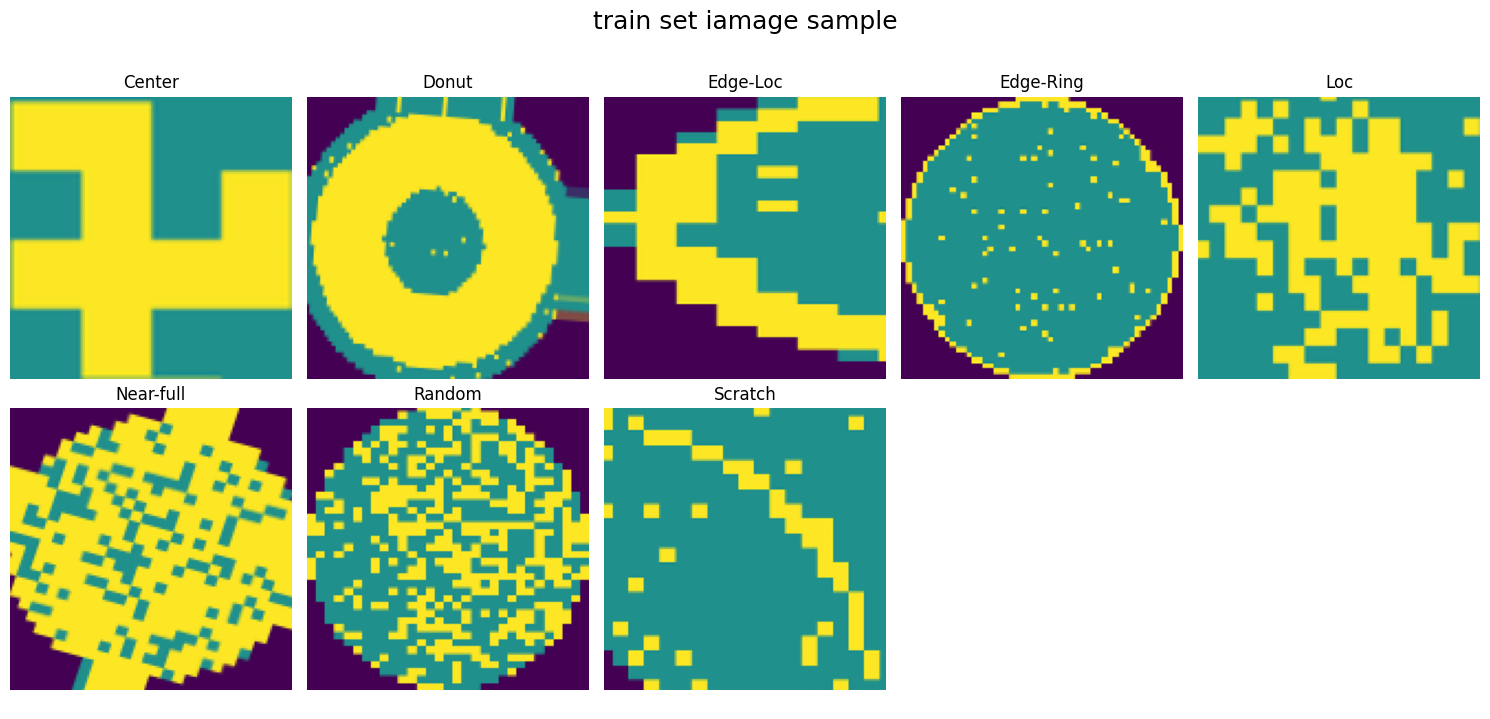

In [7]:
unique_classes = encoder.classes_
num_classes = len(unique_classes)

# 출력될 이미지 크기 설정
cols = 5
rows = math.ceil(num_classes / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
axes = axes.flatten()

# 각 클래스 별 이미지 출력
for i, class_name in enumerate(unique_classes):

  class_code = encoder.transform([class_name])[0]

  # 각 클래스의 첫 이미지 선정
  idx_in_train_set = np.where(y_train_labels == class_code)[0][0]

  # 훈련 데이터셋에서 이미지 로드
  sample_image = X_img_train[idx_in_train_set]

  # 격자를 통해 이미지 출력
  ax = axes[i]
  ax.imshow(sample_image)
  ax.set_title(class_name, fontsize=12)
  ax.axis('off')

# 격자의 빈 공간 제거
for j in range(i + 1, len(axes)):
  axes[j].axis('off')

plt.suptitle('train set iamage sample', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

# **모델 학습**

In [8]:
# 모델 학습 결과 시각화 함수
def plot_training_history(history, model_name):

  # 정확도 그래프
  plt.figure(figsize=(14, 5))
  plt.subplot(1, 2, 1)
  plt.plot(history.history['accuracy'], label='Training Accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
  plt.title(f'{model_name} - Accuracy', fontsize=14)
  plt.xlabel('Epoch', fontsize=12)
  plt.ylabel('Accuracy', fontsize=12)
  plt.legend()
  plt.grid(True)

  # 손실 그래프
  plt.subplot(1, 2, 2)
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title(f'{model_name} - Loss', fontsize=14)
  plt.xlabel('Epoch', fontsize=12)
  plt.ylabel('Loss', fontsize=12)
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()

# 혼동 행렬 시각화 함수
def plot_confusion_matrix(y_true, y_pred_probs, class_names, normalize=False, title='Confusion Matrix'):

  # 확률을 최종 클래스 예측(인덱스)으로 변환
  y_pred_classes = np.argmax(y_pred_probs, axis=1)
  y_true_classes = np.argmax(y_true, axis=1)

  # normalize 옵션 설정
  if normalize:
    # 'true': 실제 라벨(행)을 기준으로 정규화
    cm = confusion_matrix(y_true_classes, y_pred_classes, normalize='true')
    fmt = '.2f' # 소수점 둘째 자리까지 표시
  else:
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    fmt = 'd' # 정수로 표시

  # 혼동 행렬 시각화
  plt.figure(figsize=(9, 8))
  sns.heatmap(
    cm,
    annot=True,
    fmt=fmt, # [개선 2] 포맷 변경
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
  )

  plt.xlabel('Predicted Class', fontsize=12)
  plt.ylabel('Actual Class', fontsize=12)
  plt.title(title, fontsize=15)
  plt.show()


## **1. Multi-Input NN**

In [9]:
# --- 모델 구성 ---

# 1. 입력층 정의 (이미지와 좌표, 두 종류의 입력을 받음)
image_input = Input(shape=(128, 128, 3), name='image_input')
coords_input = Input(shape=(4,), name='coords_input')

# 2-1. 이미지 처리 브랜치
image_flatten = Flatten()(image_input)
image_features = Dense(128, activation='relu')(image_flatten)

# 2-2. 좌표 처리 브랜치
coords_features = Dense(16, activation='relu')(coords_input)

# 3. 브랜치 결합
combined = concatenate([image_features, coords_features])

# 4. 최종 분류층
x1 = Dense(64, activation='relu')(combined)

# 출력층
output = Dense(num_classes, activation='softmax')(x1)  # num_classes: 최종 분류할 클래스의 개수

# 5. 최종 모델 생성
model_simple_nn = Model(inputs=[image_input, coords_input], outputs=output)

# 모델 구조 확인
model_simple_nn.summary()

# --- 모델 컴파일 ---
model_simple_nn.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # 다중 클래스 분류용 손실 함수
    metrics=['accuracy']
)

# --- 모델 훈련 ---

# 조기 종료(Early Stopping) 콜백 설정
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 모델 훈련 실행
history_simple_nn = model_simple_nn.fit(
    [X_img_train, X_coords_train], y_train, # 훈련 데이터를 리스트로 전달
    epochs=50,
    batch_size=32,
    validation_data=([X_img_test, X_coords_test], y_test), # 검증 데이터도 리스트로 전달
    callbacks=[early_stopping]
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 49152)     │          0 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ coords_input        │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │  6,291,584 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │         80 │ coords_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 144)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      9,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 8)         │        520 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,301,464 (24.04 MB)

 Trainable params: 6,301,464 (24.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5237 - loss: 3.0910 - val_accuracy: 0.7188 - val_loss: 0.7225
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7865 - loss: 0.6231 - val_accuracy: 0.8281 - val_loss: 0.5217
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7987 - loss: 0.5729 - val_accuracy: 0.7794 - val_loss: 0.6811
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8436 - loss: 0.4299 - val_accuracy: 0.8100 - val_loss: 0.5989
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8317 - loss: 0.4638 - val_accuracy: 0.8044 - val_loss: 0.5434
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8490 - loss: 0.4063 - val_accuracy: 0.8125 - val_loss: 0.5691
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8559 - loss: 0.3917 - val_accuracy: 0.7763 - val_loss: 0.7083


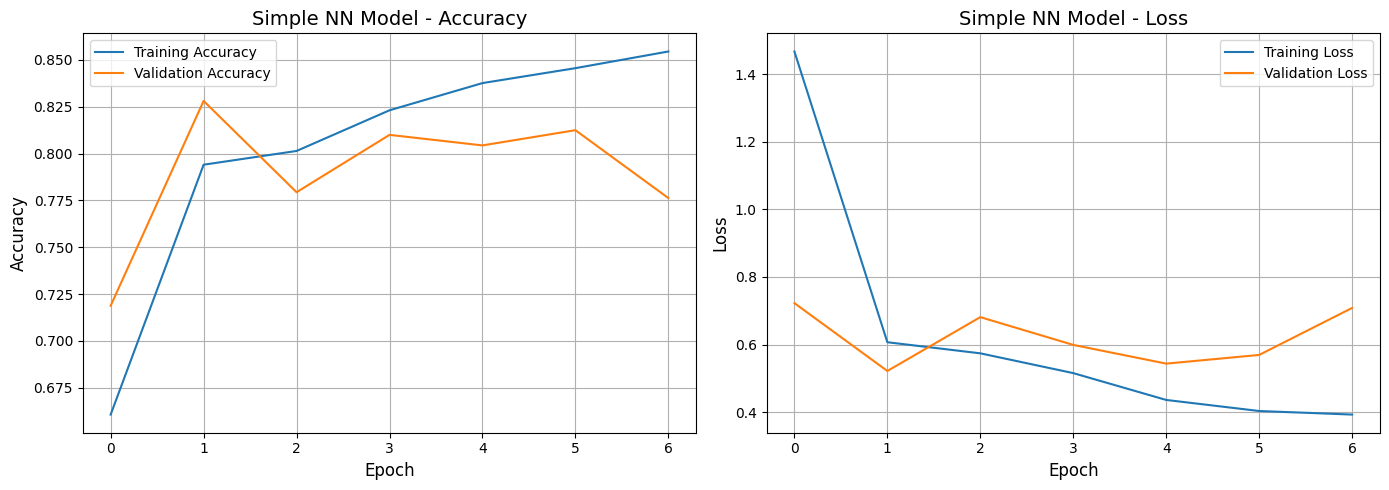

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


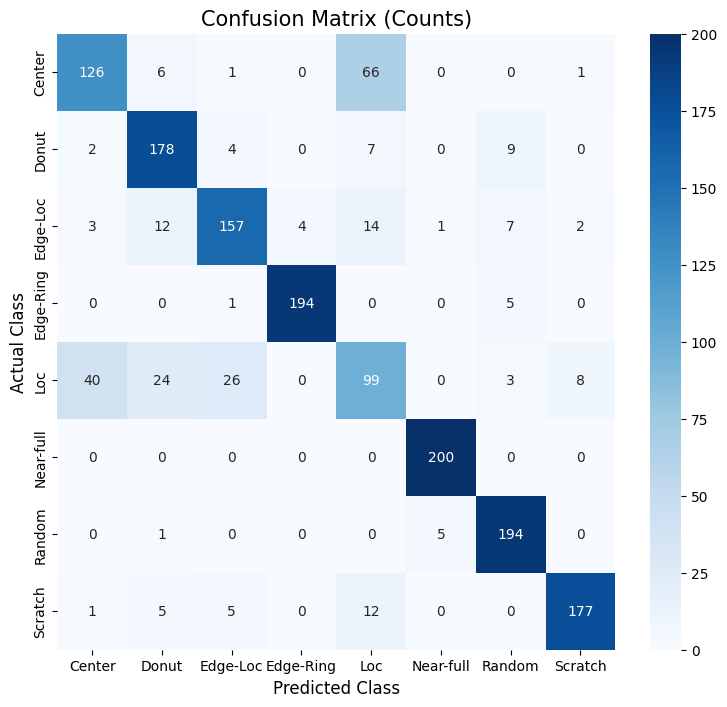

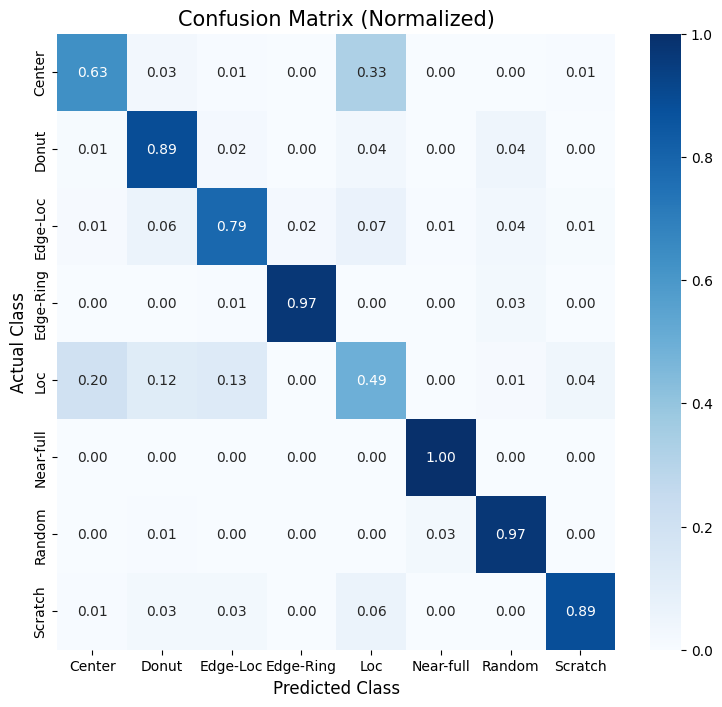

In [10]:
# 훈련 모델 성능 시각화
plot_training_history(history_simple_nn, "Simple NN Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_simple_nn.predict([X_img_test, X_coords_test])

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **2. Multi-Input DNN**

In [11]:
# --- 모델 구성 ---

# 입력층 설정
image_input = Input(shape=(128, 128, 3), name='image_input')
coords_input = Input(shape=(4,), name='coords_input')

# 이미지 처리 브랜치
image_flatten = Flatten()(image_input)
image_features = Dense(128, activation='relu')(image_flatten)
image_features = Dense(64, activation='relu')(image_features)

# 좌표 처리 브랜치
coords_features = Dense(16, activation='relu')(coords_input)
coords_features = Dense(8, activation='relu')(coords_features)

# 브랜치 결합
combined = concatenate([image_features, coords_features])

# 최종 분류층
x2 = Dense(64, activation='relu')(combined)
output = Dense(classes_num, activation='softmax')(x2)

# 최종 모델 생성
model_multi_input_dnn = Model(inputs=[image_input, coords_input], outputs=output)

# 모델 구조 확인
model_multi_input_dnn.summary()

# --- 모델 컴파일 ---
model_multi_input_dnn.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)
# --- 모델 학습 ---

# 조기 종료 콜백 설정
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 모델 훈련 실행
history_dnn = model_multi_input_dnn.fit(
  [X_img_train, X_coords_train], y_train,
  epochs=50,
  batch_size=32,
  validation_data=([X_img_test, X_coords_test], y_test),
  callbacks=[early_stopping]
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 49152)     │          0 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ coords_input        │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │  6,291,584 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │         80 │ coords_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 8)         │        136 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 72)        │          0 │ dense_5[0][0],    │
│ (Concatenate)       │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │      4,672 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 8)         │        520 │ dense_8[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,305,248 (24.05 MB)

 Trainable params: 6,305,248 (24.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4821 - loss: 3.2958 - val_accuracy: 0.7731 - val_loss: 0.6110
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7621 - loss: 0.6450 - val_accuracy: 0.8075 - val_loss: 0.5096
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8080 - loss: 0.5318 - val_accuracy: 0.8356 - val_loss: 0.4569
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8568 - loss: 0.4000 - val_accuracy: 0.8219 - val_loss: 0.4936
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8589 - loss: 0.3962 - val_accuracy: 0.8594 - val_loss: 0.4420
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8755 - loss: 0.3521 - val_accuracy: 0.8369 - val_loss: 0.4858
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8823 - loss: 0.3323 - val_accuracy: 0.8394 - val_loss: 0.4633
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8893 - loss: 0.3169 - val_accuracy: 0

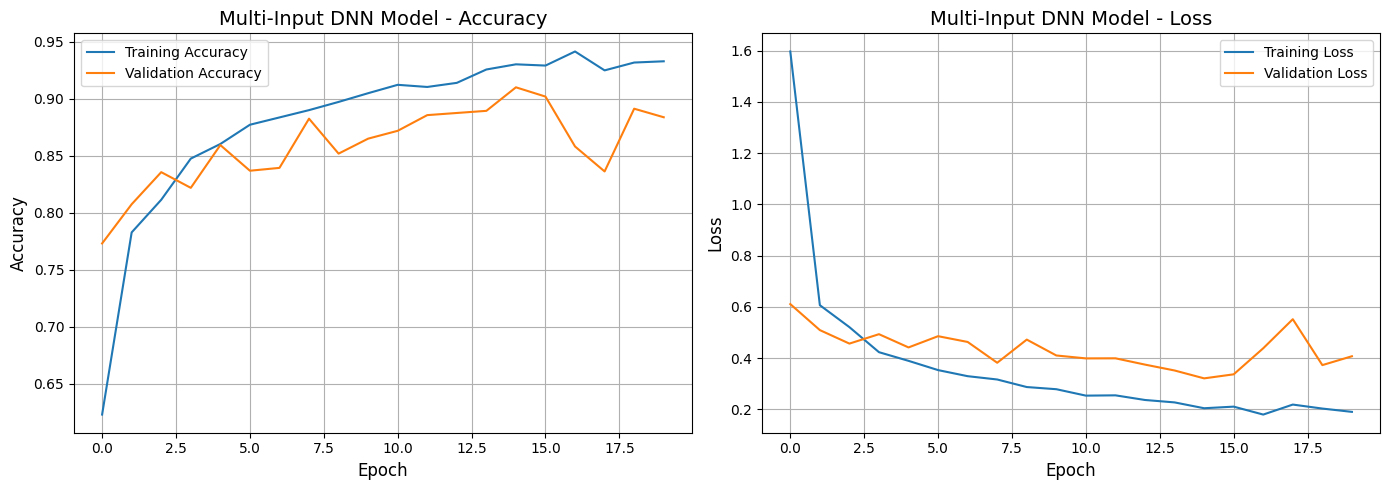

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


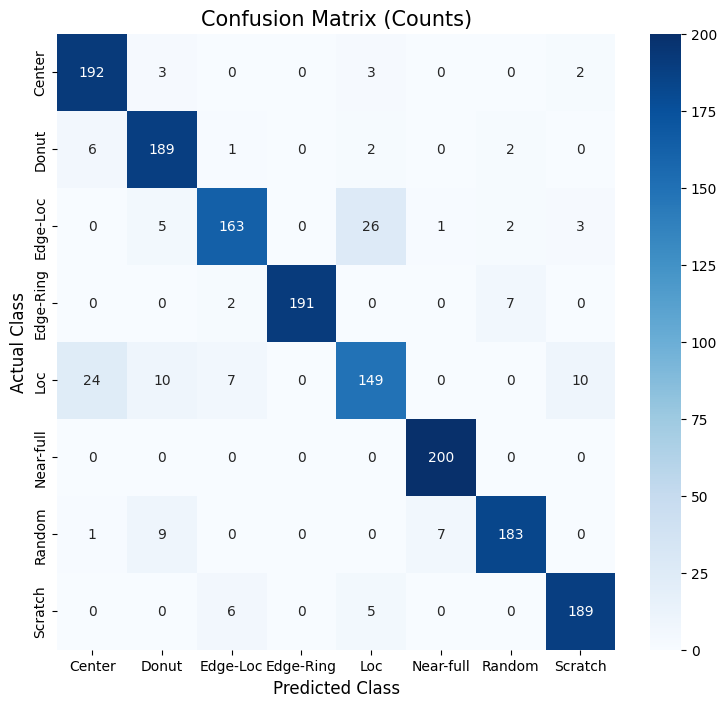

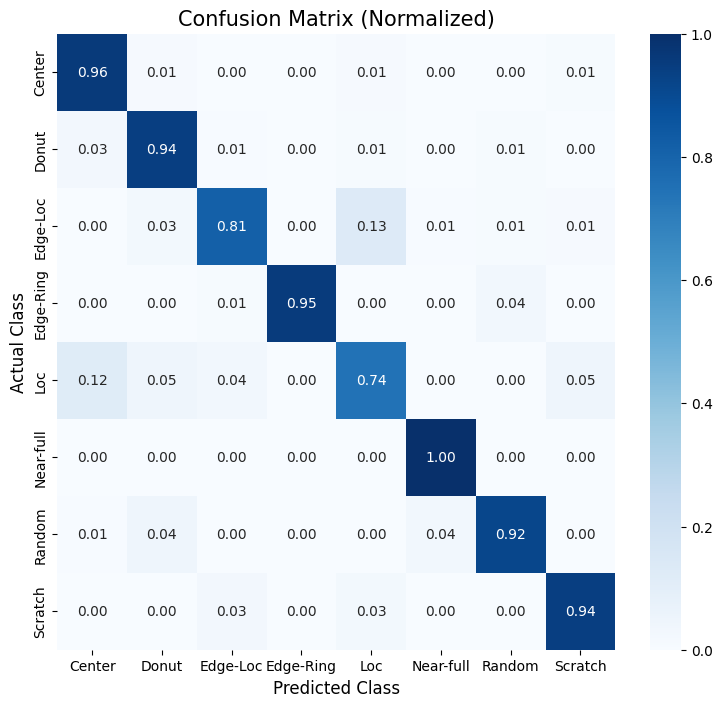

In [12]:
# 훈련 모델 성능 시각화
plot_training_history(history_dnn, "Multi-Input DNN Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_multi_input_dnn.predict([X_img_test, X_coords_test])

# 훈동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **3. Multi-Input ANN**

In [13]:
# --- 모델 구성 ---

# 입력층 정의
image_input = Input(shape=(128, 128, 3), name='image_input')
coords_input = Input(shape=(4,), name='coords_input')


# 이미지 처리 브랜치
x3 = Flatten()(image_input)
x3 = Dense(256)(x3)
x3 = LeakyReLU(alpha=0.2)(x3) # LeakyReLU 활성화 함수 사용
x3 = Dropout(0.5)(x3)         # 과적합 방지를 위한 Dropout (50% 뉴런 비활성화)

x = Dense(128)(x3)
x = LeakyReLU(alpha=0.2)(x3)
x = Dropout(0.5)(x3)
image_features = x3 # 이미지 브랜치의 최종 특징


# 좌표 처리 브랜치
coords_features = Dense(16, activation='relu')(coords_input)


# 브랜치 결합
combined = concatenate([image_features, coords_features])


# 최종 분류층
z3 = Dense(64, activation='relu')(combined)
output = Dense(classes_num, activation='softmax')(z3) # NUM_CLASSES는 이전에 정의된 클래스 개수


# 최종 모델 생성
model_multi_input_ann = Model(inputs=[image_input, coords_input], outputs=output)

# 모델 구조 확인
model_multi_input_ann.summary()


# --- 모델 컴파일 ---
model_multi_input_ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


# --- 모델 학습 ---

# 조기 종료 콜백 설정
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True) # patience 증가

# 모델 훈련 실행
history_ann = model_multi_input_ann.fit(
    [X_img_train, X_coords_train], y_train,
    epochs=100, # 더 깊어진 모델이므로 epoch을 늘려 충분히 학습
    batch_size=32,
    validation_data=([X_img_test, X_coords_test], y_test),
    callbacks=[early_stopping]
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 49152)     │          0 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256)       │ 12,583,168 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 256)       │          0 │ dense_10[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ coords_input        │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 16)        │         80 │ coords_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 272)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 64)        │     17,472 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 8)         │        520 │ dense_13[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,601,240 (48.07 MB)

 Trainable params: 12,601,240 (48.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.2859 - loss: 9.3301 - val_accuracy: 0.4794 - val_loss: 1.2221
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4594 - loss: 1.3678 - val_accuracy: 0.5238 - val_loss: 1.1175
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5176 - loss: 1.2019 - val_accuracy: 0.6069 - val_loss: 0.9728
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5620 - loss: 1.1071 - val_accuracy: 0.6319 - val_loss: 1.0220
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5709 - loss: 1.0562 - val_accuracy: 0.6662 - val_loss: 0.8733
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6177 - loss: 0.9315 - val_accuracy: 0.6913 - val_loss: 0.7859
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6286 - loss: 0.9307 - val_accuracy: 0.6975 - val_loss: 0.7870
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6500 - loss: 0.8550 - val_acc

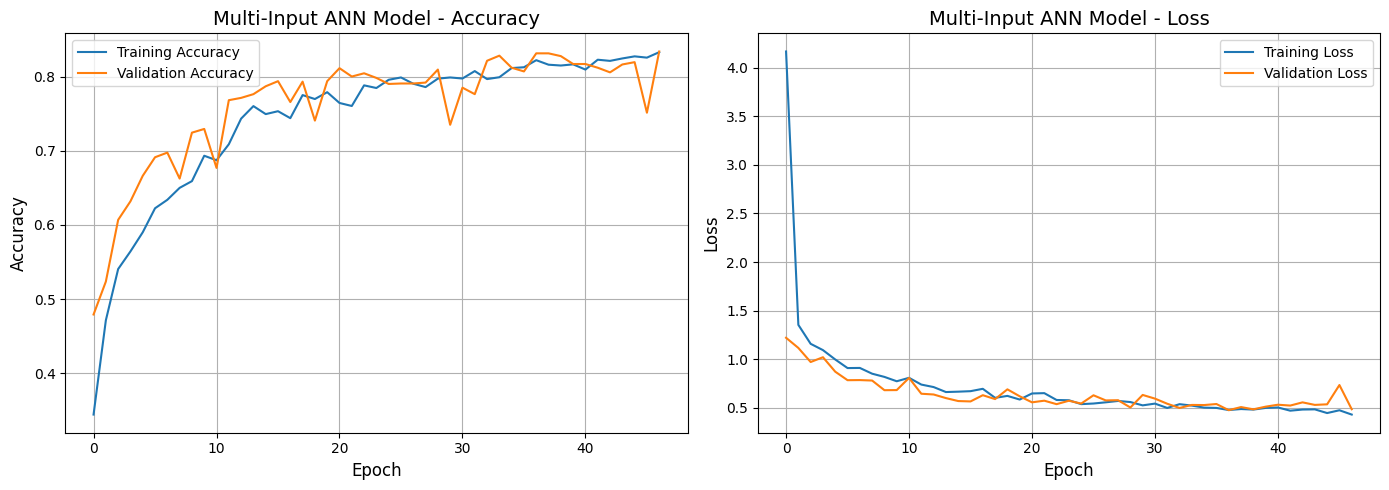

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


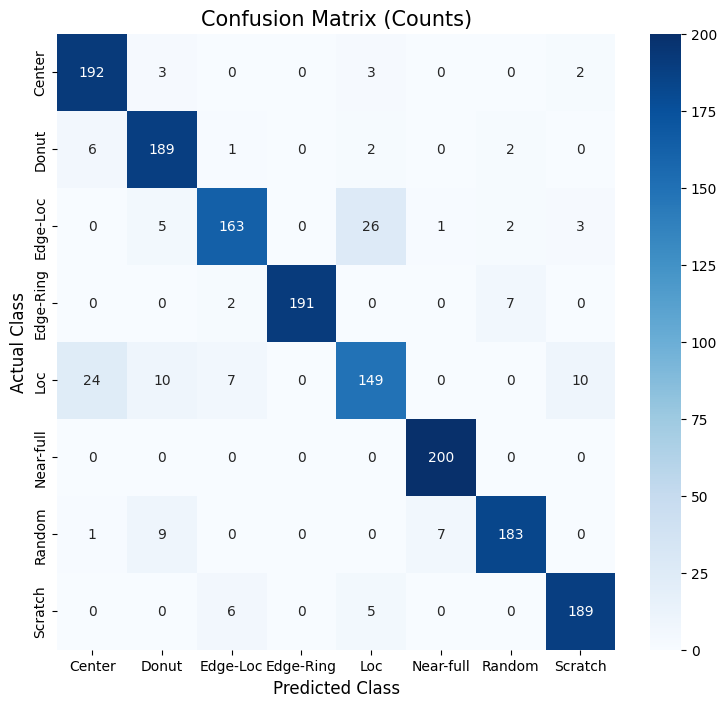

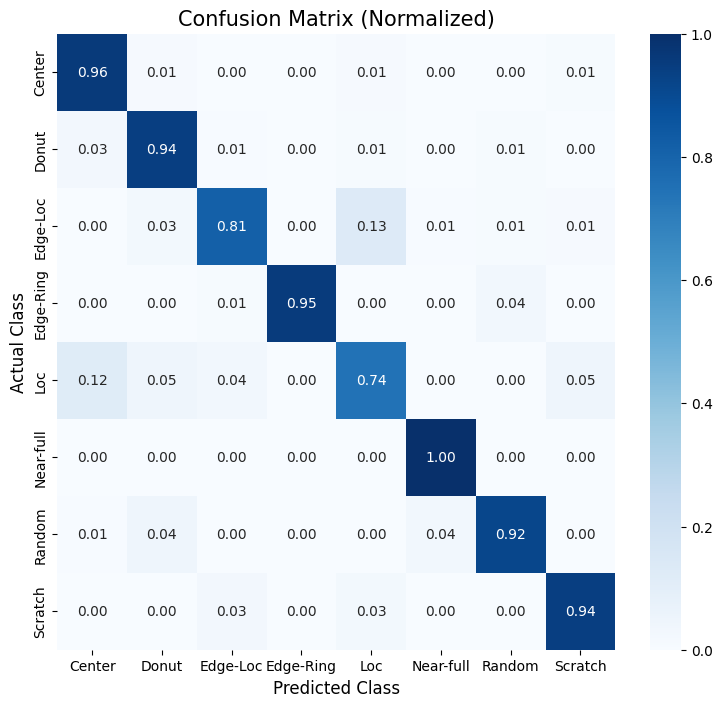

In [14]:
# 훈련 모델 성능 시각화
plot_training_history(history_ann, "Multi-Input ANN Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_multi_input_dnn.predict([X_img_test, X_coords_test])

# 훈동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **4. Multi-Input CNN**

In [15]:
# --- 모델 구성 ---

# 입력층
image_input = Input(shape=(128, 128, 3), name='image_input')
coords_input = Input(shape=(4,), name='coords_input')

# 이미지 처리 브랜치 (CNN 블록 설정)

# Conv-Pool Block 1
x4 = Conv2D(32, (3, 3), activation='relu')(image_input)
x4 = BatchNormalization()(x4)
x4 = MaxPooling2D(pool_size=(2, 2))(x4)
x4 = Dropout(0.3)(x4)

# Conv-Pool Block 2
x4 = Conv2D(64, (3, 3), activation='relu')(x4)
x4 = BatchNormalization()(x4)
x4 = MaxPooling2D(pool_size=(2, 2))(x4)
x4 = Dropout(0.3)(x4)

# Conv-Pool Block 3
x4 = Conv2D(128, (3, 3), activation='relu')(x4)
x4 = BatchNormalization()(x4)
x4 = MaxPooling2D(pool_size=(2, 2))(x4)
x4 = Dropout(0.5)(x4)

# 이미지 처리 브랜치의 최종 특징 분류
image_features = Flatten()(x4)

# 좌표 처리 브랜치 (MLP 블록)
coords_features = Dense(16, activation='relu')(coords_input)

# 브랜치 결합
combined = concatenate([image_features, coords_features])

# 최종 분류층
z4 = Dense(128, activation='relu')(combined)
z4 = BatchNormalization()(z4)
z4 = Dropout(0.5)(z4)
output = Dense(classes_num, activation='softmax')(z4) # 다중 클래스 분류

# 최종 모델 생성
model_multi_input_cnn = Model(inputs=[image_input, coords_input], outputs=output)

# 모델 구조 확인
model_multi_input_cnn.summary()

# --- 모델 컴파일 ---

# Adam 옵티마이저 설정
optimizer = Adam(learning_rate=0.0001)
model_multi_input_cnn.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# --- 모델 학습 ---

# 조기 종료 콜백 설정
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 모델 훈련 실행
history_cnn = model_multi_input_cnn.fit(
  [X_img_train, X_coords_train], y_train,
  epochs=100,
  batch_size=32,
  validation_data=([X_img_test, X_coords_test], y_test),
  callbacks=[early_stopping]
)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 126, 126,  │        896 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 126, 126,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 63, 63,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 63, 63,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 61, 61,    │     18,496 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 61,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 30, 30,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 30, 30,    │          0 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     73,856 │ dropout_3[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 14, 14,    │          0 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ coords_input        │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 25088)     │          0 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 16)        │         80 │ coords_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 25104)     │          0 │ flatten_3[0][0],  │
│ (Concatenate)       │                   │            │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 3,309,208 (12.62 MB)

 Trainable params: 3,308,504 (12.62 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.5497 - loss: 1.4208 - val_accuracy: 0.1250 - val_loss: 5.6639
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7508 - loss: 0.7079 - val_accuracy: 0.1762 - val_loss: 5.9725
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.7922 - loss: 0.5926 - val_accuracy: 0.3537 - val_loss: 4.5010
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8049 - loss: 0.5719 - val_accuracy: 0.5088 - val_loss: 3.7164
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8250 - loss: 0.4970 - val_accuracy: 0.5806 - val_loss: 5.9157
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8364 - loss: 0.4542 - val_accuracy: 0.6125 - val_loss: 5.0660
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8579 - loss: 0.4178 - val_accuracy: 0.6488 - val_loss: 3.8493
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8548 - loss: 0.4061 -

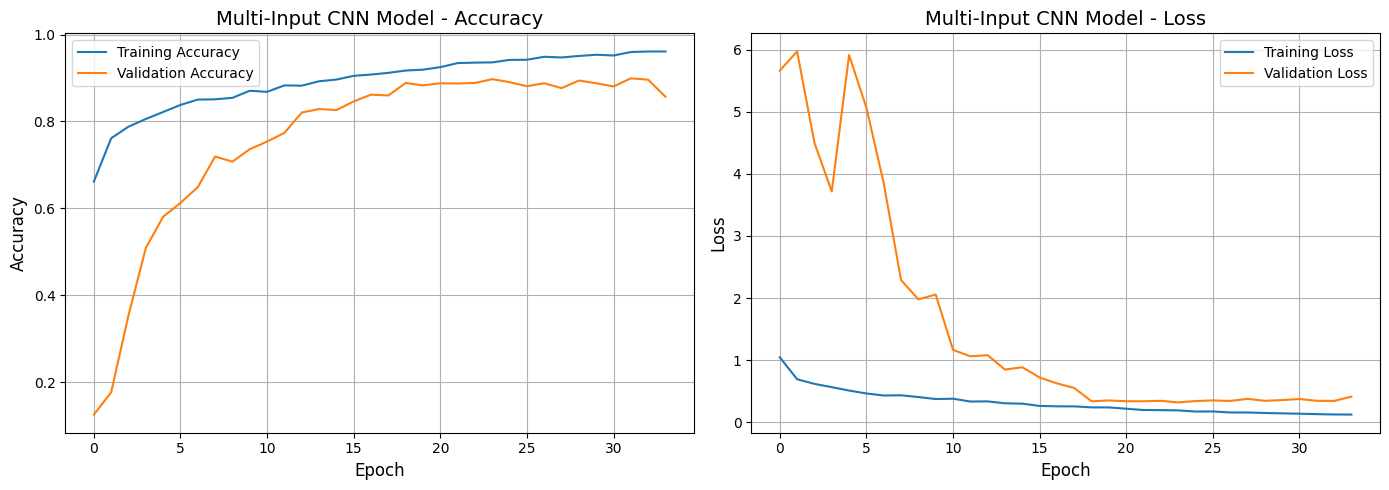

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


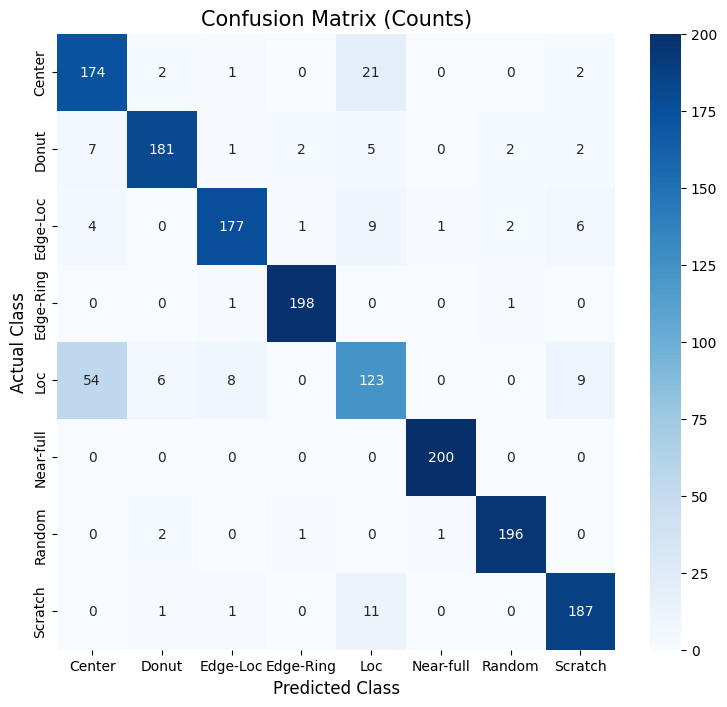

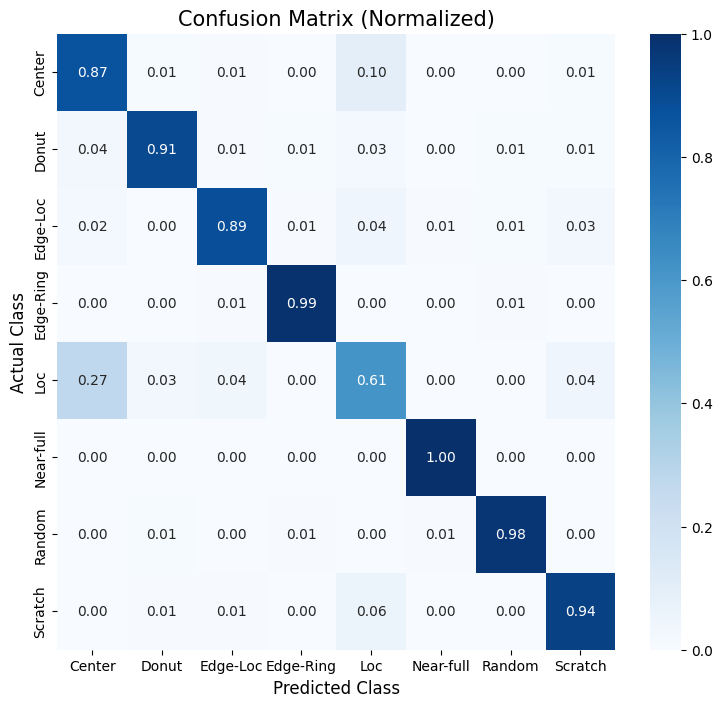

In [16]:
# 훈련 모델 성능 시각화
plot_training_history(history_cnn, "Multi-Input CNN Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_multi_input_cnn.predict([X_img_test, X_coords_test])

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **5. MobileNetV2 전이학습**

In [17]:
# --- 모델 구성 ---

# 입력층
image_input = Input(shape=(128, 128, 3), name='image_input')
coords_input = Input(shape=(4,), name='coords_input')

# 이미지 처리 브랜치 (MobileNetV2)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 MobileNetV2의 가중치 동결
base_model.trainable = False

# MobileNetV2의 출력에 커스텀 레이어 추가
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
image_features = Dropout(0.5)(x)

# 좌표 처리 브랜치 (MLP)
coords_features = Dense(16, activation='relu')(coords_input)

# 브랜치 결합
combined = concatenate([image_features, coords_features])

# 최종 분류층
z = Dense(64, activation='relu')(combined)
z = Dropout(0.5)(z)
output = Dense(num_classes, activation='softmax')(z) # 다중 클래스 분류

# 최종 모델 생성
model_multi_input_mobilenetv2 = Model(inputs=[image_input, coords_input], outputs=output)

# 모델 구조 확인
model_multi_input_mobilenetv2.summary()

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_multi_input_mobilenetv2.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# --- 모델 학습 ---

# 조기 종료 콜백 설정
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 모델 훈련 실행
history_mobilenetv2 = model_multi_input_mobilenetv2.fit(
  [X_img_train, X_coords_train], y_train,
  epochs=100,
  batch_size=32,
  validation_data=([X_img_test, X_coords_test], y_test),
  callbacks=[early_stopping]
)

/tmp/ipython-input-2261057025.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=image_input)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,431,832 (9.28 MB)

 Trainable params: 173,848 (679.09 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.2487 - loss: 2.3200 - val_accuracy: 0.6381 - val_loss: 1.1983
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4574 - loss: 1.4364 - val_accuracy: 0.6619 - val_loss: 0.9848
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5372 - loss: 1.2605 - val_accuracy: 0.6888 - val_loss: 0.8897
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5748 - loss: 1.1667 - val_accuracy: 0.6906 - val_loss: 0.8351
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6022 - loss: 1.1043 - val_accuracy: 0.7081 - val_loss: 0.7859
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6055 - loss: 1.0215 - val_accuracy: 0.7225 - val_loss: 0.7583
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6383 - loss: 0.9944 - val_accuracy: 0.7287 - val_loss: 0.7328
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6437 - loss: 0.9631 -

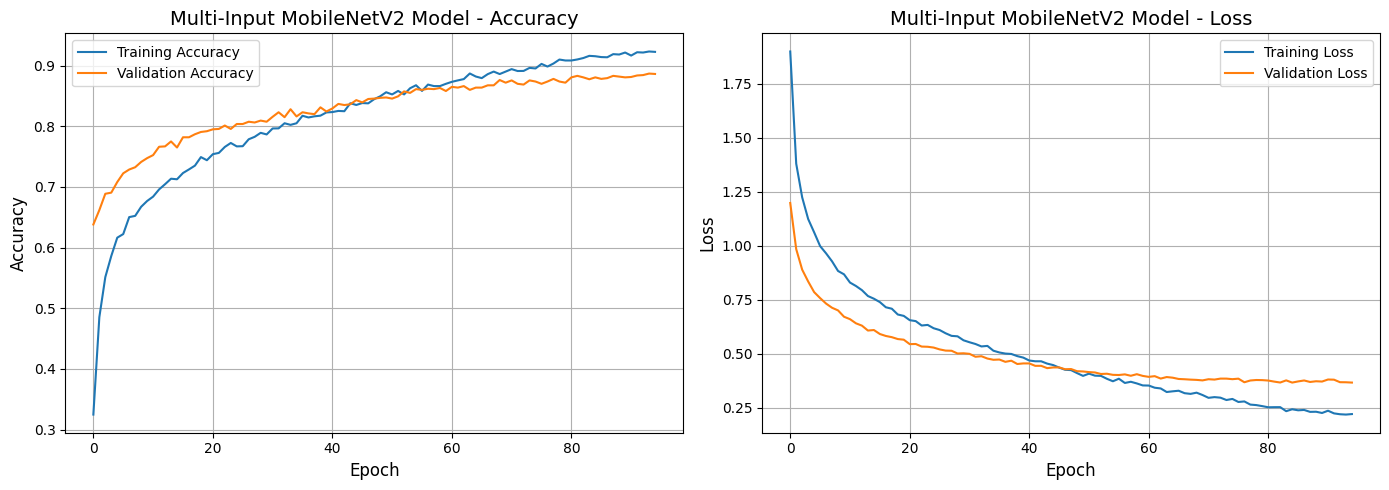

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


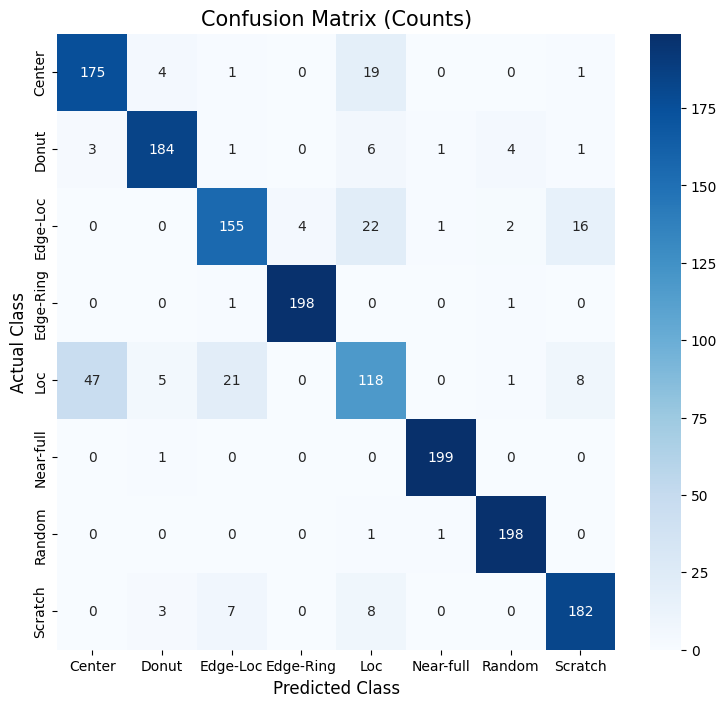

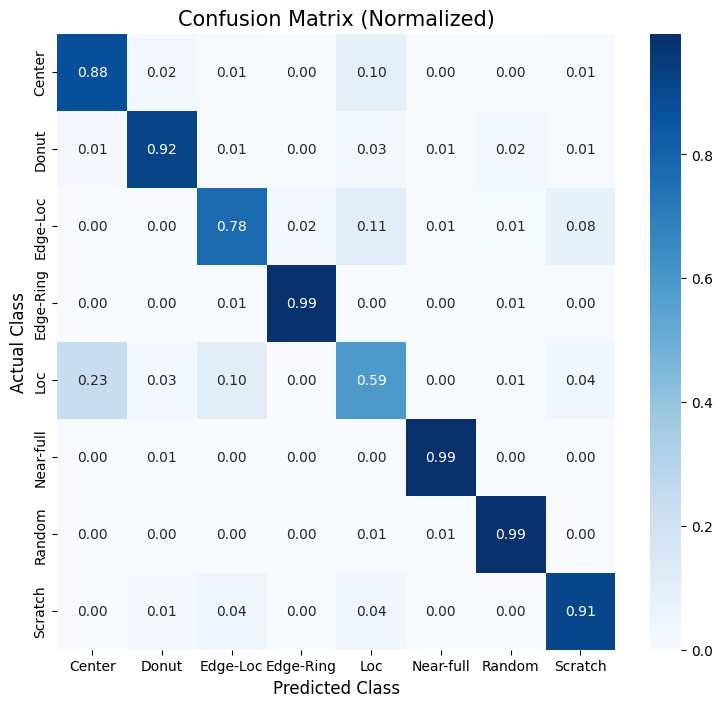

In [18]:
# 훈련 모델 성능 시각화
plot_training_history(history_mobilenetv2, "Multi-Input MobileNetV2 Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_multi_input_mobilenetv2.predict([X_img_test, X_coords_test])

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **6. MobileNetV3Small 전이학습**

In [19]:
# --- 모델 구성 ---

# 입력층
image_input = Input(shape=(128, 128, 3), name='image_input')
coords_input = Input(shape=(4,), name='coords_input')


# 이미지 처리 브랜치 (MobileNetV3Small)
base_model = MobileNetV3Small(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 MobileNetV3의 가중치 동결
base_model.trainable = False

# MobileNetV3Small의 출력에 커스텀 레이어 추가
x6 = base_model.output
x6 = GlobalAveragePooling2D()(x6)
x6 = Dense(128, activation='relu')(x6)
image_features = Dropout(0.5)(x6)


# 좌표 처리 브랜치 (MLP)
coords_features = Dense(16, activation='relu')(coords_input)


# 브랜치 결합
combined = concatenate([image_features, coords_features])


# 최종 분류층
z6 = Dense(64, activation='relu')(combined)
z6 = Dropout(0.5)(z6)
output = Dense(num_classes, activation='softmax')(z6) # 다중 클래스 분류


# 최종 모델 생성
model_multi_input_mobilenetv3 = Model(inputs=[image_input, coords_input], outputs=output)

# 모델 구조 확인
model_multi_input_mobilenetv3.summary()


# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_multi_input_mobilenetv3.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])


# --- 모델 학습 ---

# 조기 종료 콜백 설정
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 모델 훈련 실행
history_mobilenetv3 = model_multi_input_mobilenetv3.fit(
    [X_img_train, X_coords_train], y_train,
    epochs=100,
    batch_size=32,
    validation_data=([X_img_test, X_coords_test], y_test),
    callbacks=[early_stopping]
)

/usr/local/lib/python3.11/dist-packages/keras/src/applications/mobilenet_v3.py:452: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ image_input[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 64, 64,    │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 64, 64,    │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 65, 65,    │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 32, 32,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │        256 │ expanded_conv_sq

 Total params: 1,022,856 (3.90 MB)

 Trainable params: 83,736 (327.09 KB)

 Non-trainable params: 939,120 (3.58 MB)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.1471 - loss: 2.2841 - val_accuracy: 0.2037 - val_loss: 1.9708
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.2091 - loss: 1.9756 - val_accuracy: 0.3113 - val_loss: 1.8450
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2616 - loss: 1.8605 - val_accuracy: 0.3631 - val_loss: 1.7145
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2889 - loss: 1.7681 - val_accuracy: 0.4100 - val_loss: 1.6162
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3147 - loss: 1.6894 - val_accuracy: 0.4206 - val_loss: 1.5424
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3326 - loss: 1.6289 - val_accuracy: 0.4756 - val_loss: 1.4926
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3648 - loss: 1.5721 - val_accuracy: 0.4988 - val_loss: 1.4499
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3734 - loss: 1.5432 -

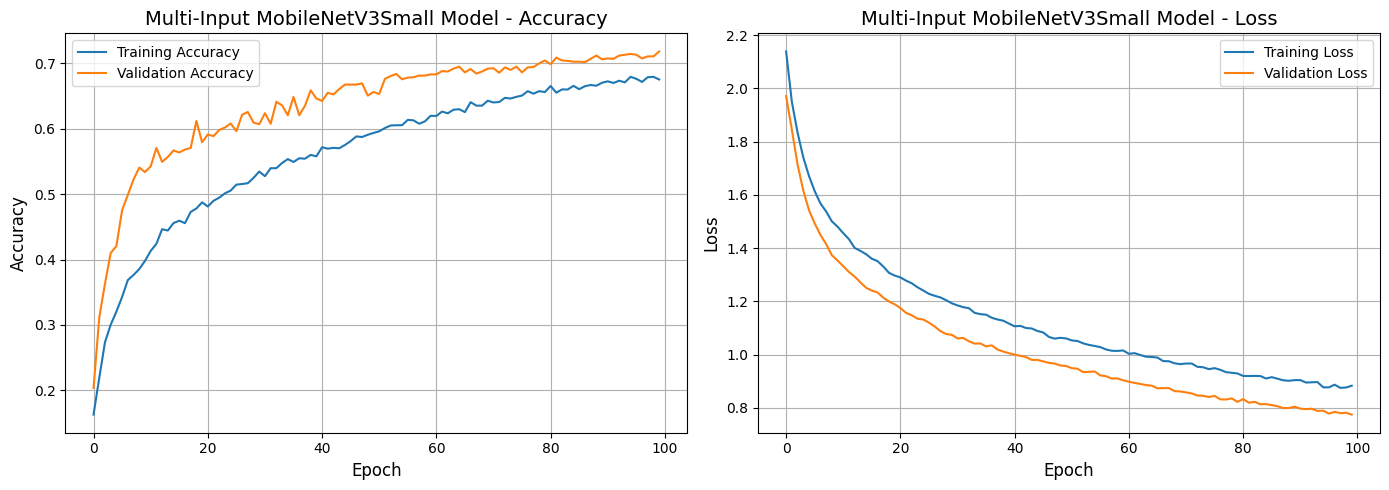

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step


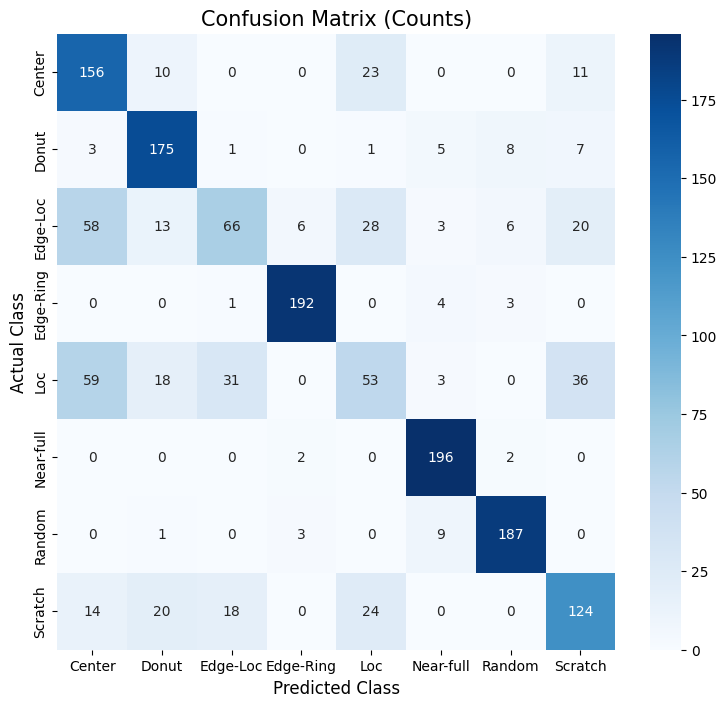

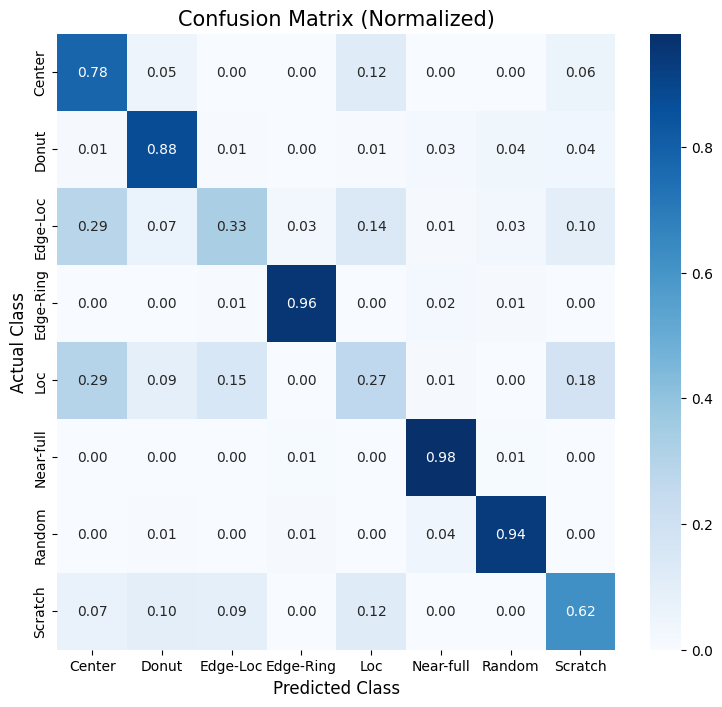

In [20]:
# 훈련 모델 성능 시각화
plot_training_history(history_mobilenetv3, "Multi-Input MobileNetV3Small Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_multi_input_mobilenetv3.predict([X_img_test, X_coords_test])

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **7. ResNet50 전이학습**

In [21]:
# --- 모델 구성 ---

# 입력층
image_input = Input(shape=(128, 128, 3), name='image_input')
coords_input = Input(shape=(4,), name='coords_input')

# 이미지 처리 브랜치 (ResNet50)
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 ResNet50의 가중치 동결
base_model.trainable = False

# ResNet50의 출력에 커스텀 레이어 추가
x7 = base_model.output
x7 = GlobalAveragePooling2D()(x7)
x7 = Dense(128, activation='relu')(x7)
image_features = Dropout(0.5)(x7)

# 좌표 처리 브랜치 (MLP)
coords_features = Dense(16, activation='relu')(coords_input)

# 브랜치 결합
combined = concatenate([image_features, coords_features])

# 최종 분류층
z7 = Dense(64, activation='relu')(combined)
z7 = Dropout(0.5)(z7)
output = Dense(num_classes, activation='softmax')(z7) # 다중 클래스 분류

# 최종 모델 생성
model_multi_input_resnet50 = Model(inputs=[image_input, coords_input], outputs=output)

# 모델 구조 확인
model_multi_input_resnet50.summary()

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_multi_input_resnet50.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# --- 모델 학습 ---

# 조기 종료 콜백 설정
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 모델 훈련 실행
history_resnet50 = model_multi_input_resnet50.fit(
  [X_img_train, X_coords_train], y_train,
  epochs=100,
  batch_size=32,
  validation_data=([X_img_test, X_coords_test], y_test),
  callbacks=[early_stopping]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ image_input[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,859,864 (91.02 MB)

 Trainable params: 272,152 (1.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 64ms/step - accuracy: 0.1336 - loss: 2.2437 - val_accuracy: 0.2231 - val_loss: 2.0307
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.1555 - loss: 2.0683 - val_accuracy: 0.3269 - val_loss: 1.9845
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.2056 - loss: 2.0002 - val_accuracy: 0.2869 - val_loss: 1.9257
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.2551 - loss: 1.9364 - val_accuracy: 0.3325 - val_loss: 1.8424
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.2712 - loss: 1.8641 - val_accuracy: 0.5031 - val_loss: 1.7517
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.2875 - loss: 1.7929 - val_accuracy: 0.4925 - val_loss: 1.6589
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.3060 - loss: 1.7046 - val_accuracy: 0.4956 - val_loss: 1.5770
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.3465 - loss: 1.6238 -

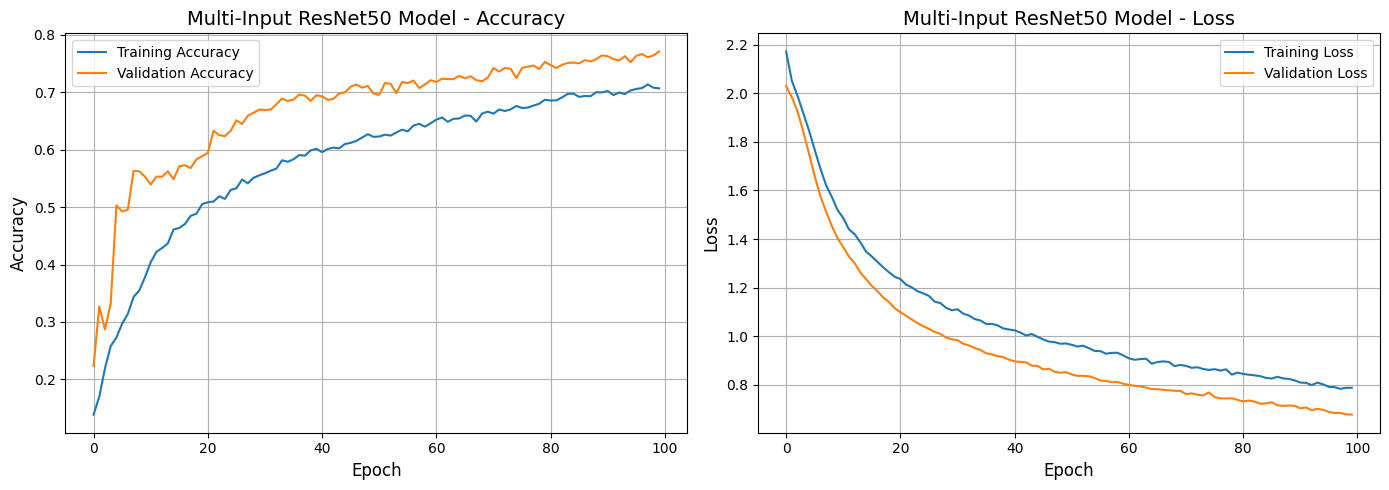

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step


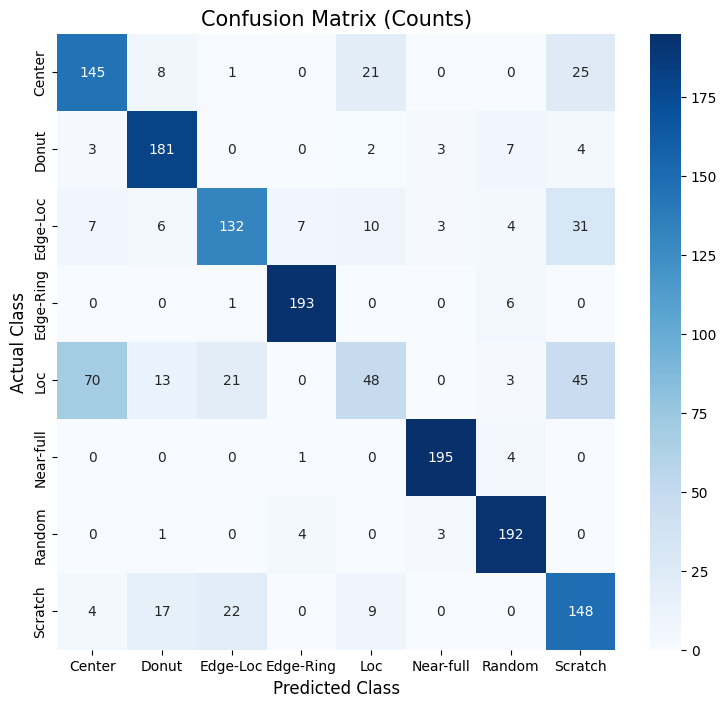

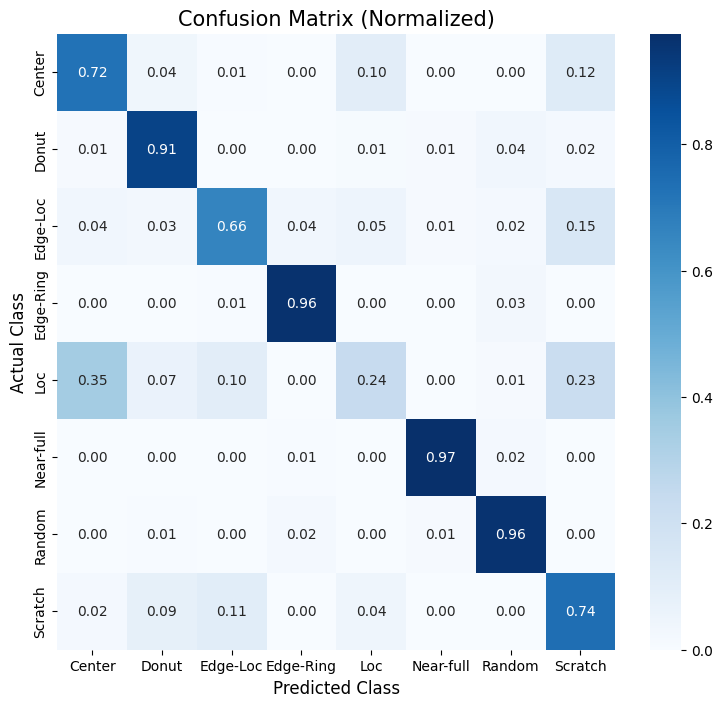

In [22]:
# 훈련 모델 성능 시각화
plot_training_history(history_resnet50, "Multi-Input ResNet50 Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_multi_input_resnet50.predict([X_img_test, X_coords_test])

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **8. VGG16 전이학습**

In [23]:
# --- 모델 구성 ---

# 입력층
image_input = Input(shape=(128, 128, 3), name='image_input')
coords_input = Input(shape=(4,), name='coords_input')

# 이미지 처리 브랜치 (VGG16)
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 VGG16의 가중치 동결
base_model.trainable = False

# VGG16의 출력에 커스텀 레이어 추가
x8 = base_model.output
x8 = GlobalAveragePooling2D()(x8)
x8 = Dense(128, activation='relu')(x8)
image_features = Dropout(0.5)(x8)

# 좌표 처리 브랜치 (MLP)
coords_features = Dense(16, activation='relu')(coords_input)

# 브랜치 결합
combined = concatenate([image_features, coords_features])

# 최종 분류층
z8 = Dense(64, activation='relu')(combined)
z8 = Dropout(0.5)(z8)
output = Dense(num_classes, activation='softmax')(z8) # 다중 클래스 분류

# 최종 모델 생성
model_multi_input_vgg16 = Model(inputs=[image_input, coords_input], outputs=output)

# 모델 구조 확인
model_multi_input_vgg16.summary()

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_multi_input_vgg16.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# --- 모델 학습 ---

# 조기 종료 콜백 설정
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 모델 훈련 실행
history_vgg16 = model_multi_input_vgg16.fit(
  [X_img_train, X_coords_train], y_train,
  epochs=100,
  batch_size=32,
  validation_data=([X_img_test, X_coords_test], y_test),
  callbacks=[early_stopping]
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 128, 128,  │      1,792 │ image_input[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 128, 128,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 64, 64,    │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 64, 64,    │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 64, 64,    │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 32, 32,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 32, 32,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 32, 32,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 32, 32,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 16, 16,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 16, 16,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 16, 16,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 16, 16,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 8, 8, 512) │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 8, 8, 512) │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 8, 8, 512) │  2,359,808 │ block5_conv1[0][

 Total params: 14,790,232 (56.42 MB)

 Trainable params: 75,544 (295.09 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 80ms/step - accuracy: 0.1596 - loss: 2.2019 - val_accuracy: 0.4631 - val_loss: 1.7384
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - accuracy: 0.3312 - loss: 1.7646 - val_accuracy: 0.5962 - val_loss: 1.3761
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.4423 - loss: 1.5301 - val_accuracy: 0.6581 - val_loss: 1.1562
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.5075 - loss: 1.3387 - val_accuracy: 0.6819 - val_loss: 1.0223
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.5463 - loss: 1.2362 - val_accuracy: 0.7212 - val_loss: 0.9385
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.5863 - loss: 1.1296 - val_accuracy: 0.7344 - val_loss: 0.8698
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.6121 - loss: 1.0623 - val_accuracy: 0.7475 - val_loss: 0.8256
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.6330 - loss: 1

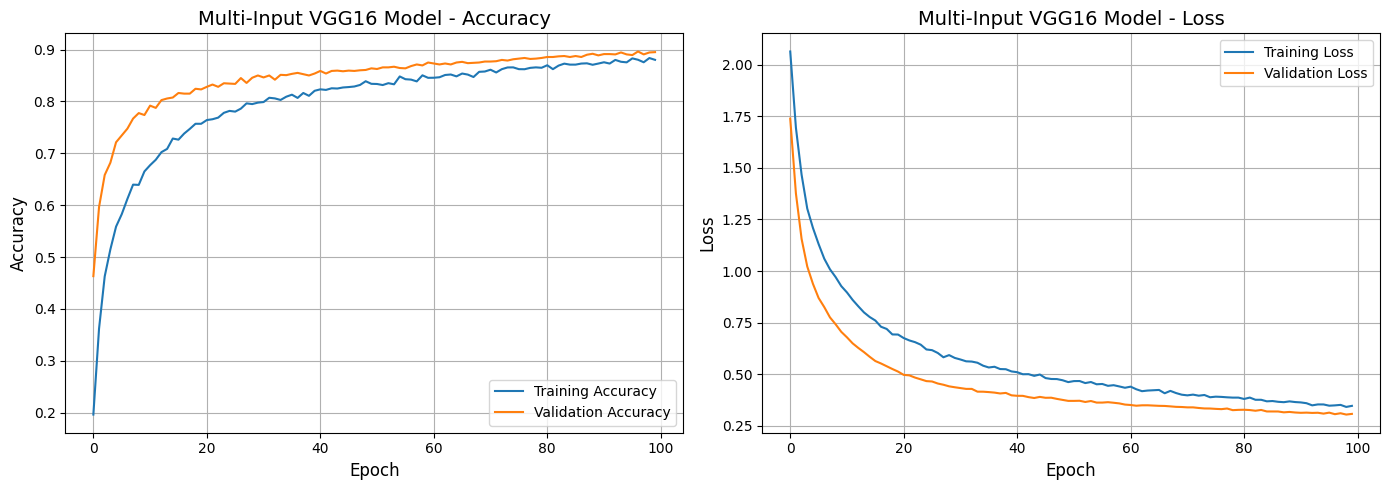

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step


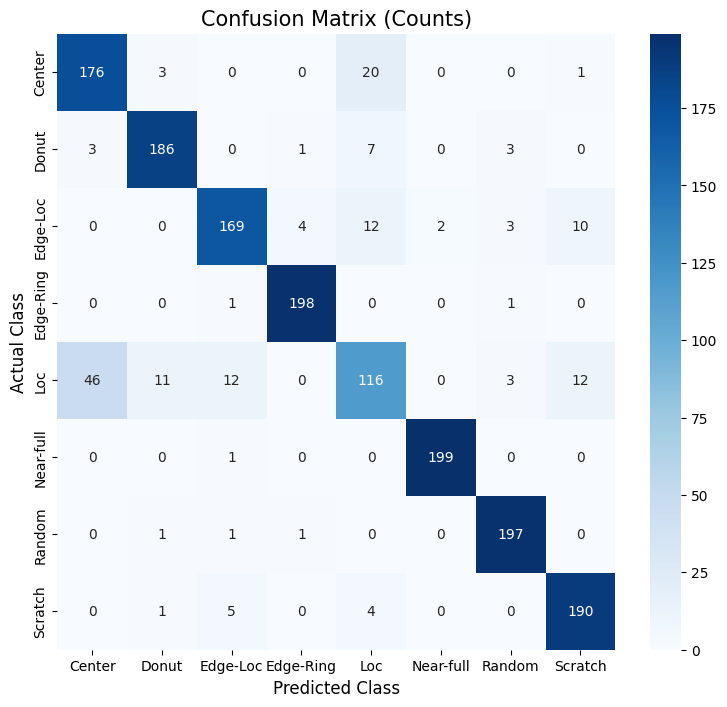

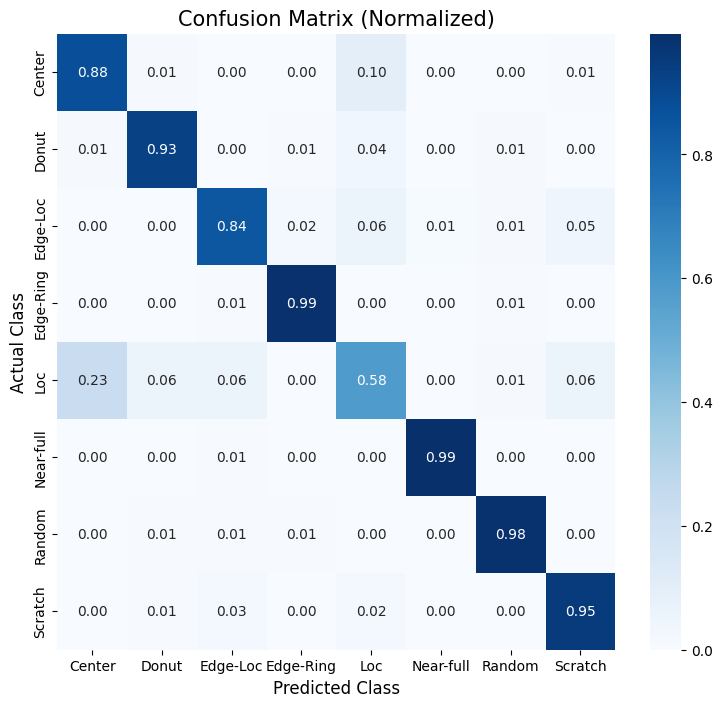

In [24]:
# 훈련 모델 성능 시각화
plot_training_history(history_vgg16, "Multi-Input VGG16 Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_multi_input_vgg16.predict([X_img_test, X_coords_test])

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **9. InceptionV3 전이학습**

In [25]:
# --- 모델 구성 ---

# 입력층
image_input = Input(shape=(128, 128, 3), name='image_input')
coords_input = Input(shape=(4,), name='coords_input')

# 이미지 처리 브랜치 (InceptionV3)
base_model = InceptionV3(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 InceptionV3의 가중치 동결
base_model.trainable = False

# InceptionV3의 출력에 커스텀 레이어 추가
x9 = base_model.output
x9 = GlobalAveragePooling2D()(x9)
x9 = Dense(128, activation='relu')(x9)
image_features = Dropout(0.5)(x9)

# 좌표 처리 브랜치 (MLP)
coords_features = Dense(16, activation='relu')(coords_input)

# 브랜치 결합
combined = concatenate([image_features, coords_features])

# 최종 분류층
z9 = Dense(64, activation='relu')(combined)
z9 = Dropout(0.5)(z9)
output = Dense(num_classes, activation='softmax')(z9) # 다중 클래스 분류

# 최종 모델 생성
model_multi_input_inceptionv3 = Model(inputs=[image_input, coords_input], outputs=output)

# 모델 구조 확인
model_multi_input_inceptionv3.summary()

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_multi_input_inceptionv3.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# --- 모델 학습 ---

# 조기 종료 콜백 설정
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 모델 훈련 실행
history_inceptionv3 = model_multi_input_inceptionv3.fit(
  [X_img_train, X_coords_train], y_train,
  epochs=100,
  batch_size=32,
  validation_data=([X_img_test, X_coords_test], y_test),
  callbacks=[early_stopping]
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 63, 63,    │        864 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 63, 63,    │         96 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 63, 63,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 61, 61,    │      9,216 │ activation_18[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 61,    │         96 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 61, 61,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 61, 61,    │     18,432 │ activation_19[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 61,    │        192 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 61, 61,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 30, 30,    │          0 │ activation_20[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 30, 30,    │      5,120 │ max_pooling2d_3[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 30,    │        240 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 30, 30,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 28, 28,    │    138,240 │ activation_21[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        576 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 28, 28,    │          0 │ batch_normalizat

 Total params: 22,074,936 (84.21 MB)

 Trainable params: 272,152 (1.04 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.2207 - loss: 2.5102 - val_accuracy: 0.6181 - val_loss: 1.2729
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.4558 - loss: 1.4851 - val_accuracy: 0.6569 - val_loss: 1.0050
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.5376 - loss: 1.2821 - val_accuracy: 0.7025 - val_loss: 0.8610
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.6031 - loss: 1.1132 - val_accuracy: 0.7369 - val_loss: 0.8003
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.6348 - loss: 1.0137 - val_accuracy: 0.7588 - val_loss: 0.7259
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.6498 - loss: 0.9890 - val_accuracy: 0.7538 - val_loss: 0.6964
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.6743 - loss: 0.9127 - val_accuracy: 0.7713 - val_loss: 0.6544
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.6748 - loss: 0.8820 -

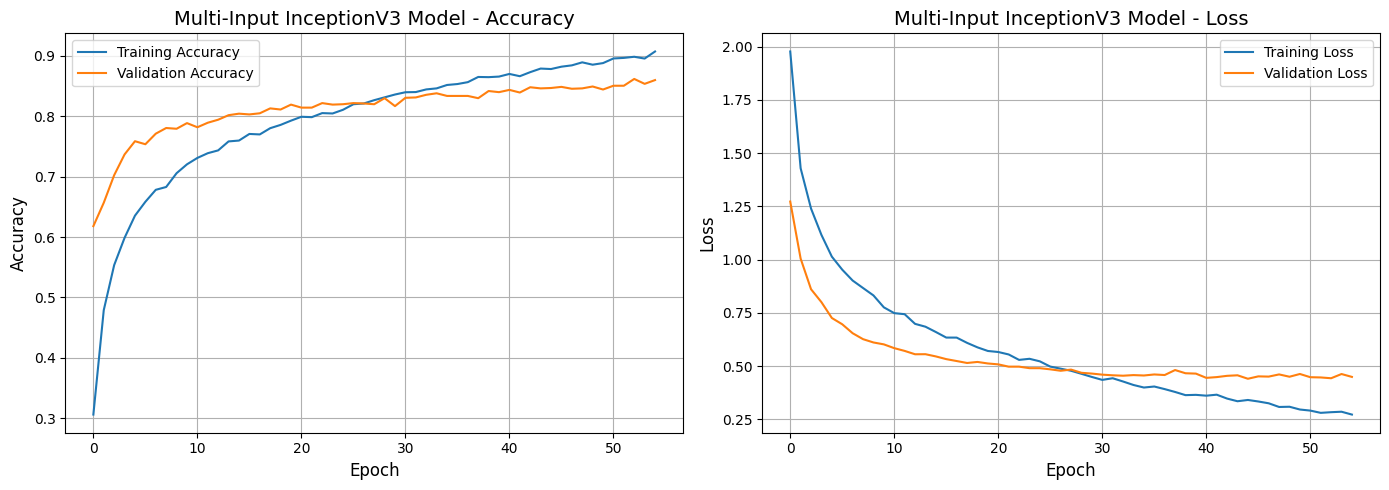

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step


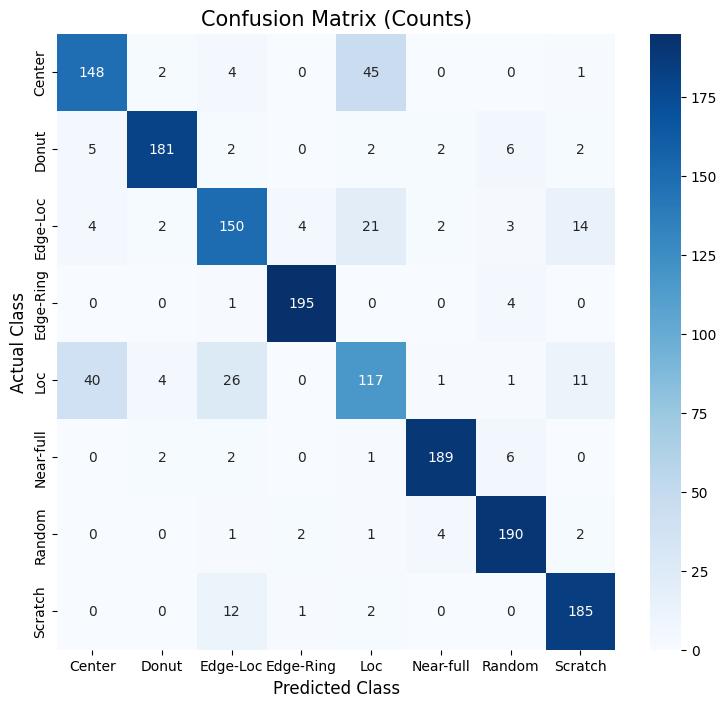

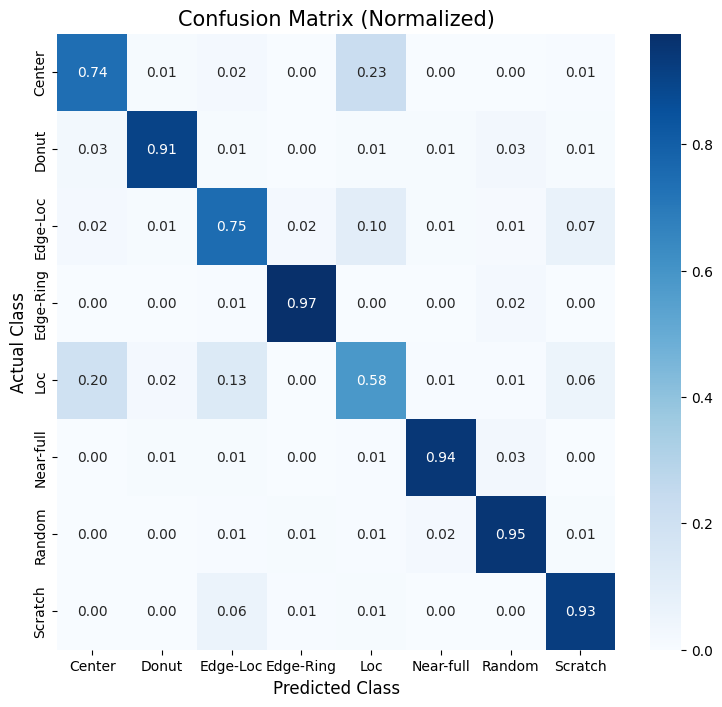

In [26]:
# 훈련 모델 성능 시각화
plot_training_history(history_inceptionv3, "Multi-Input InceptionV3 Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_multi_input_inceptionv3.predict([X_img_test, X_coords_test])

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **10. Xception 전이학습**

In [27]:
# --- 모델 구성 ---

# 입력층
image_input = Input(shape=(128, 128, 3), name='image_input')
coords_input = Input(shape=(4,), name='coords_input')

# 이미지 처리 브랜치 (Xception)
base_model = Xception(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 Xception의 가중치 동결
base_model.trainable = False

# Xception의 출력에 커스텀 레이어 추가
x10 = base_model.output
x10 = GlobalAveragePooling2D()(x10)
x10 = Dense(128, activation='relu')(x10)
image_features = Dropout(0.5)(x10)

# 좌표 처리 브랜치 (MLP)
coords_features = Dense(16, activation='relu')(coords_input)

# 브랜치 결합
combined = concatenate([image_features, coords_features])

# 최종 분류층
z10 = Dense(64, activation='relu')(combined)
z10 = Dropout(0.5)(z10)
output = Dense(num_classes, activation='softmax')(z10) # 다중 클래스 분류

# 최종 모델 생성
model_multi_input_xception = Model(inputs=[image_input, coords_input], outputs=output)

# 모델 구조 확인
model_multi_input_xception.summary()

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_multi_input_xception.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# --- 모델 학습 ---

# 조기 종료 콜백 설정
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 모델 훈련 실행
history_xception = model_multi_input_xception.fit(
  [X_img_train, X_coords_train], y_train,
  epochs=100,
  batch_size=32,
  validation_data=([X_img_test, X_coords_test], y_test),
  callbacks=[early_stopping]
)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 63, 63,    │        864 │ image_input[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 63, 63,    │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 63, 63,    │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 61, 61,    │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 61, 61,    │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 61, 61,    │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 61, 61,    │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 61, 61,    │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 61, 61,    │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 61, 61,    │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 61, 61,    │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 31, 31,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 31, 31,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 31,    │        512 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 31, 31,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 31, 31,    │          0 │ add_9[0][0]     

 Total params: 21,133,632 (80.62 MB)

 Trainable params: 272,152 (1.04 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 23s 69ms/step - accuracy: 0.2882 - loss: 1.8773 - val_accuracy: 0.6450 - val_loss: 1.2035
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.5398 - loss: 1.3301 - val_accuracy: 0.7144 - val_loss: 0.9426
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.6117 - loss: 1.1187 - val_accuracy: 0.7206 - val_loss: 0.8224
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.6344 - loss: 1.0110 - val_accuracy: 0.7487 - val_loss: 0.7589
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.6691 - loss: 0.9431 - val_accuracy: 0.7594 - val_loss: 0.7150
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.7020 - loss: 0.8863 - val_accuracy: 0.7669 - val_loss: 0.6791
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.7095 - loss: 0.8161 - val_accuracy: 0.7706 - val_loss: 0.6542
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.7250 - loss: 0

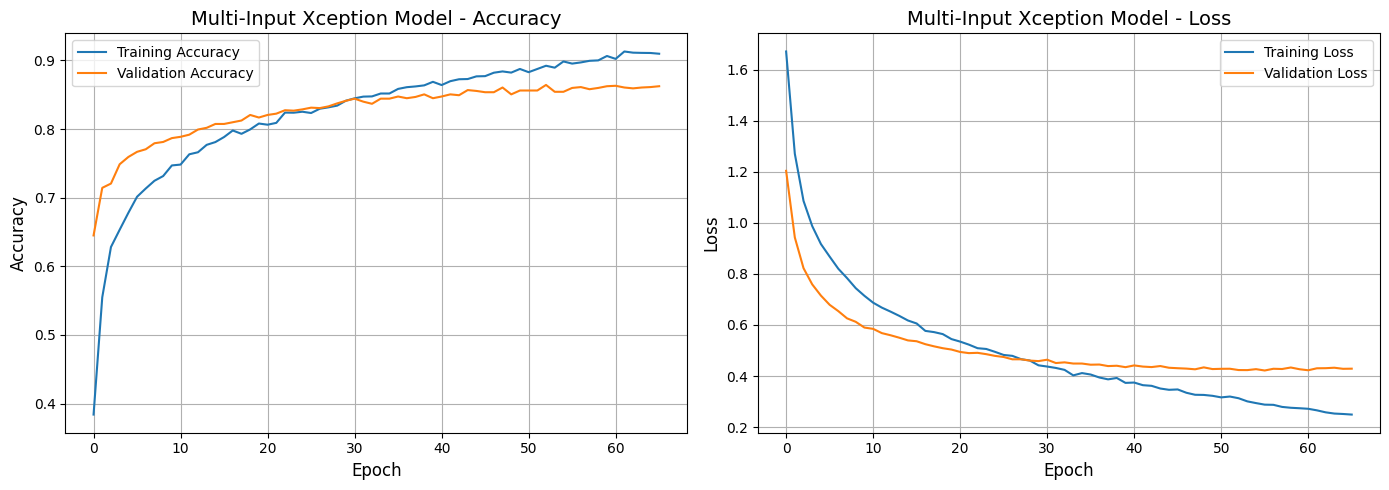

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step


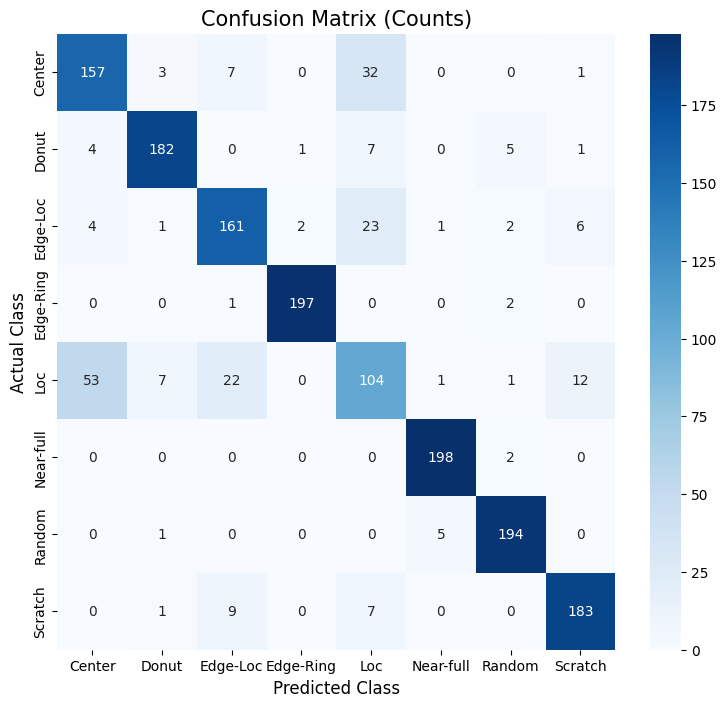

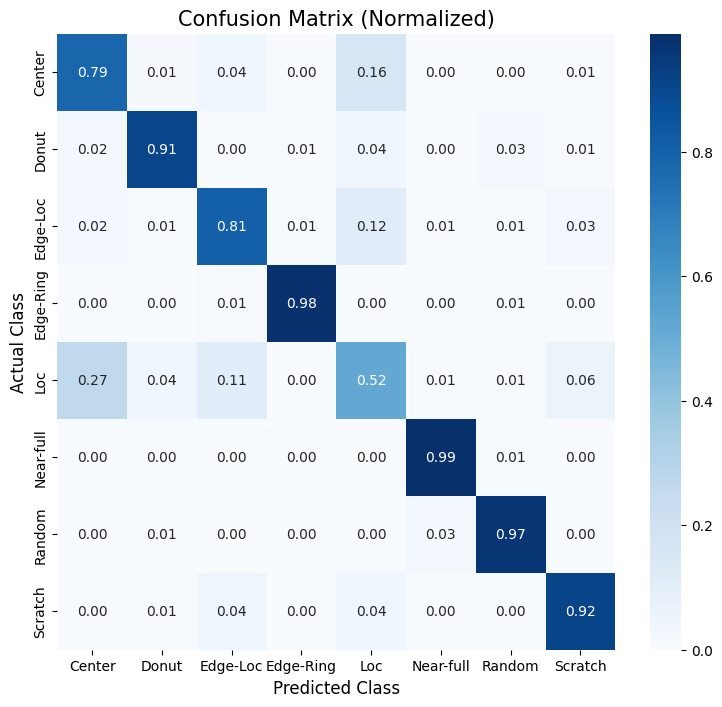

In [28]:
# 훈련 모델 성능 시각화
plot_training_history(history_xception, "Multi-Input Xception Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_multi_input_xception.predict([X_img_test, X_coords_test])

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

## **11. DenseNet121 전이학습**

In [29]:
# --- 모델 구성 ---

# 입력층
image_input = Input(shape=(128, 128, 3), name='image_input')
coords_input = Input(shape=(4,), name='coords_input')

# 이미지 처리 브랜치 (DenseNet121)
base_model = DenseNet121(weights='imagenet', include_top=False, input_tensor=image_input)

# 사전 훈련된 DenseNet121의 가중치 동결
base_model.trainable = False

# DenseNet121의 출력에 커스텀 레이어 추가
x11 = base_model.output
x11 = GlobalAveragePooling2D()(x11)
x11 = Dense(128, activation='relu')(x11)
image_features = Dropout(0.5)(x11)

# 좌표 처리 브랜치 (MLP)
coords_features = Dense(16, activation='relu')(coords_input)

# 브랜치 결합
combined = concatenate([image_features, coords_features])

# 최종 분류층
z11 = Dense(64, activation='relu')(combined)
z11 = Dropout(0.5)(z11)
output = Dense(num_classes, activation='softmax')(z11) # 다중 클래스 분류

# 최종 모델 생성
model_multi_input_densenet121 = Model(inputs=[image_input, coords_input], outputs=output)

# 모델 구조 확인
model_multi_input_densenet121.summary()

# --- 모델 컴파일 ---
optimizer = Adam(learning_rate=0.0001)
model_multi_input_densenet121.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# --- 모델 학습 ---

# 조기 종료 콜백 설정
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 모델 훈련 실행
history_densenet121 = model_multi_input_densenet121.fit(
  [X_img_train, X_coords_train], y_train,
  epochs=100,
  batch_size=32,
  validation_data=([X_img_test, X_coords_test], y_test),
  callbacks=[early_stopping]
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 134, 134,  │          0 │ image_input[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 32, 32,    │     12,288 │ conv2_block2_0_r

 Total params: 7,178,584 (27.38 MB)

 Trainable params: 141,080 (551.09 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 43s 93ms/step - accuracy: 0.2045 - loss: 2.3902 - val_accuracy: 0.5794 - val_loss: 1.3175
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.4233 - loss: 1.5139 - val_accuracy: 0.6519 - val_loss: 1.0754
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.5257 - loss: 1.2900 - val_accuracy: 0.6706 - val_loss: 0.9431
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.5578 - loss: 1.1669 - val_accuracy: 0.7044 - val_loss: 0.8664
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.6131 - loss: 1.0498 - val_accuracy: 0.7275 - val_loss: 0.8112
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.6181 - loss: 1.0103 - val_accuracy: 0.7556 - val_loss: 0.7621
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.6503 - loss: 0.9415 - val_accuracy: 0.7706 - val_loss: 0.7251
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.6737 - loss: 0.9072 -

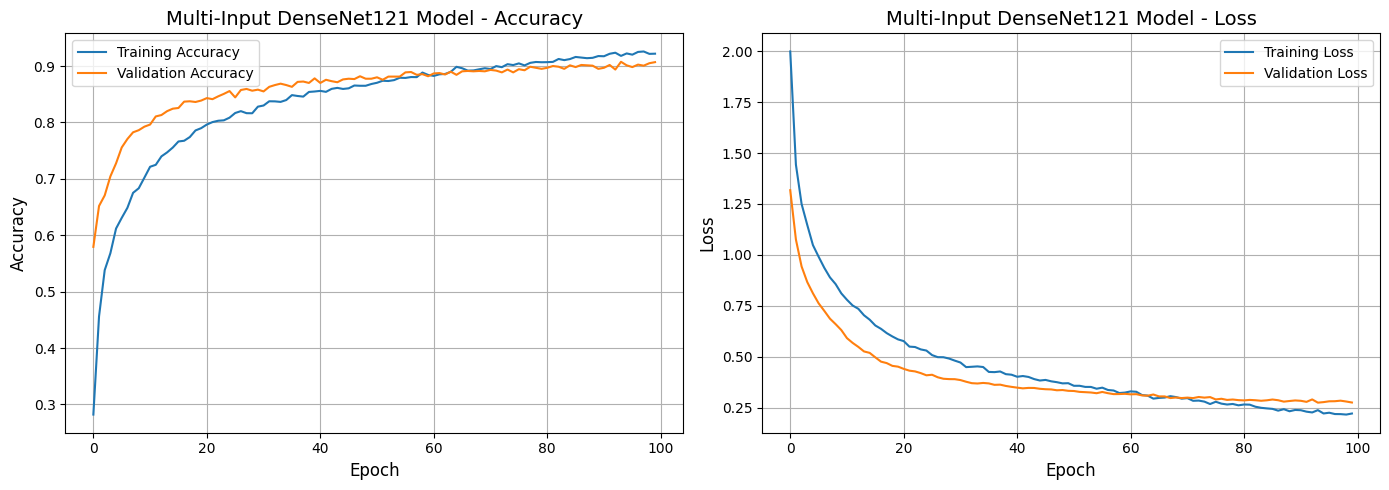

50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step


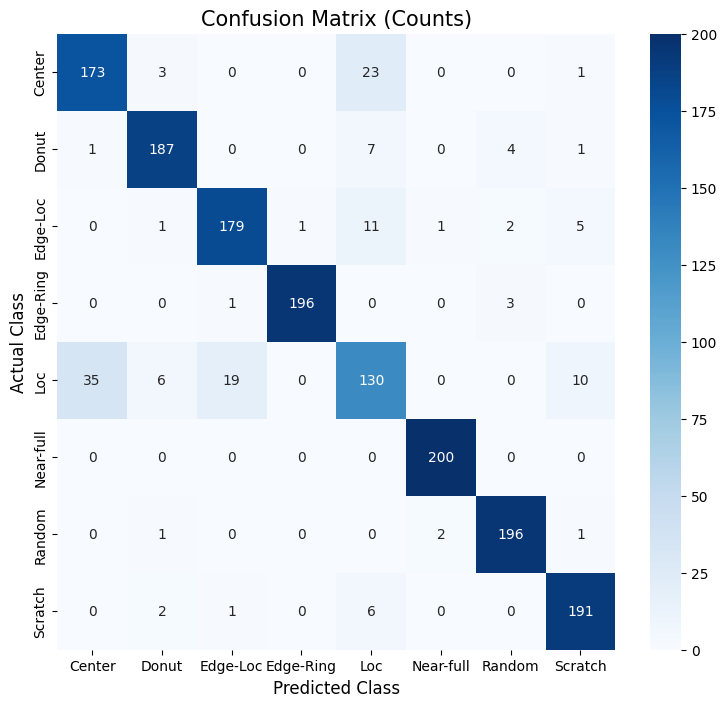

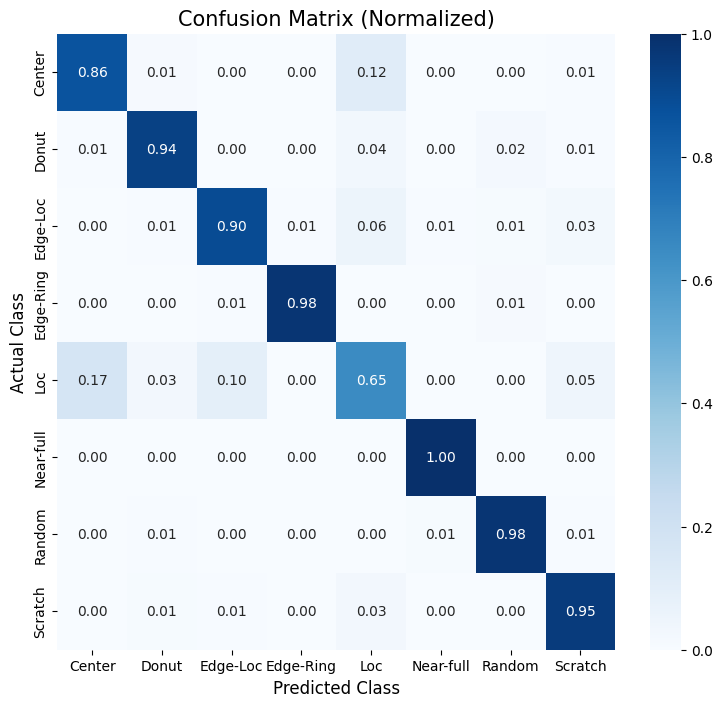

In [30]:
# 훈련 모델 성능 시각화
plot_training_history(history_densenet121, "Multi-Input DenseNet121 Model")

# 테스트 데이터로 예측 수행
y_pred_probs = model_multi_input_densenet121.predict([X_img_test, X_coords_test])

# 혼동 행렬 시각화
plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=False, title='Confusion Matrix (Counts)')

plot_confusion_matrix(y_test, y_pred_probs, encoder.classes_, normalize=True, title='Confusion Matrix (Normalized)')

# **성능 비교 결과**

In [31]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 평가할 모델들을 딕셔너리로 정의
models_to_evaluate = {
    "Multi-Input NN": model_simple_nn,
    "Multi-Input DNN": model_multi_input_dnn,
    "Multi-Input ANN": model_multi_input_ann,
    "Multi-Input CNN": model_multi_input_cnn,
    "Multi-Input MobileNetV2": model_multi_input_mobilenetv2,
    "Multi-Input MobileNetV3Small": model_multi_input_mobilenetv3,
    "Multi-Input ResNet50": model_multi_input_resnet50,
    "Multi-Input VGG16": model_multi_input_vgg16,
    "Multi-Input InceptionV3": model_multi_input_inceptionv3,
    "Multi-Input Xception": model_multi_input_xception,
    "Multi-Input DenseNet121": model_multi_input_densenet121
}

results = []

y_test_classes = np.argmax(y_test, axis=1)

# 모델 별 성능 평가
for model_name, model in models_to_evaluate.items():

  # 예측 수행
  y_pred_probs = model.predict([X_img_test, X_coords_test], verbose=0)

  # 예측된 확률을 최종 클래스로 변환
  y_pred_classes = np.argmax(y_pred_probs, axis=1)

  # 평가 지표 계산
  accuracy = accuracy_score(y_test_classes, y_pred_classes)
  precision = precision_score(y_test_classes, y_pred_classes, average='weighted', zero_division=0)
  recall = recall_score(y_test_classes, y_pred_classes, average='weighted', zero_division=0)
  f1 = f1_score(y_test_classes, y_pred_classes, average='weighted', zero_division=0)

  # 결과 저장
  results.append({
      "Model": model_name,
      "Accuracy": accuracy,
      "Precision": precision,
      "Recall": recall,
      "F1-Score": f1
  })

# 최종 결과 출력
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print("\n\n--- 최종 모델 성능 비교표 (F1-Score 기준 정렬) ---")
display(results_df_sorted)



--- 최종 모델 성능 비교표 (F1-Score 기준 정렬) ---


,Model,Accuracy,Precision,Recall,F1-Score
0,Multi-Input DNN,0.910000,0.910414,0.910000,0.909074
1,Multi-Input DenseNet121,0.907500,0.905292,0.907500,0.905934
2,Multi-Input CNN,0.897500,0.898531,0.897500,0.896464
3,Multi-Input VGG16,0.894375,0.891388,0.894375,0.891202
4,Multi-Input MobileNetV2,0.880625,0.878099,0.880625,0.878407
5,Multi-Input Xception,0.860000,0.856719,0.860000,0.857748
6,Multi-Input InceptionV3,0.846875,0.845082,0.846875,0.845628
7,Multi-Input ANN,0.831250,0.827215,0.831250,0.827781
8,Multi-Input NN,0.828125,0.826440,0.828125,0.826030
9,Multi-Input ResNet50,0.771250,0.760548,0.771250,0.756498
